# The IFT Correlated Field Model

By the end of this notebook you'll understand:
1. How a PSD encodes SFH burstiness.
2. How to read a PSD plot and predict the SFH character.
3. What σ_PS and τ_PS mean physically.

**The key equation** (Eq. 5 in the paper):

$$\ln \dot{M}_\star(t) = \ln \bar{\dot{M}}_\star(t) - K(0)/2 + x(t)$$

where $\bar{\dot{M}}_\star(t)$ is the smooth secular trend, $-K(0)/2$
is the lognormal correction ensuring the mean is preserved, and $x(t)$
is the stochastic fluctuation field drawn from a Gaussian process with
PSD $P(\omega)$.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import drw_variance
from tengri.models.sfh.psd_models import psd_drw
from tengri.models.sfh.gp_sfh import compute_sqrt_power_drw
from tengri.models.sfh.gp_sfh import gp_from_xi, generate_gp_fourier
from tengri.models.sfh.mean_sfh import tsnorm
from tengri.utils.grid import make_log_age_grid, grid_spacing

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("theory", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, setup_style

setup_style()

In [2]:
# Grid setup
N_GRID = 128
log_ages = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_ages)
ages_yr = 10**log_ages
ages_gyr = ages_yr / 1e9

## 1. The Power Spectral Density

The PSD answers: how much variability power exists at each timescale?
It fully specifies the Gaussian process prior. We use a Damped Random
Walk (DRW, or Lorentzian): $P(\omega) = \sigma^2 \tau / (1 + (\omega\tau)^2)$.

In [3]:
# Four burstiness regimes
REGIMES = [
    {"sigma": 0.5, "tau_myr": 200, "label": "Smooth (σ=0.5, τ=200)", "color": COLORS["seq"][0]},
    {"sigma": 1.0, "tau_myr": 50, "label": "Moderate (σ=1.0, τ=50)", "color": COLORS["seq"][2]},
    {"sigma": 2.0, "tau_myr": 20, "label": "Bursty (σ=2.0, τ=20)", "color": COLORS["seq"][3]},
    {"sigma": 3.0, "tau_myr": 5, "label": "Extreme (σ=3.0, τ=5)", "color": COLORS["seq"][4]},
]

W0405 03:57:28.035074 36388595 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


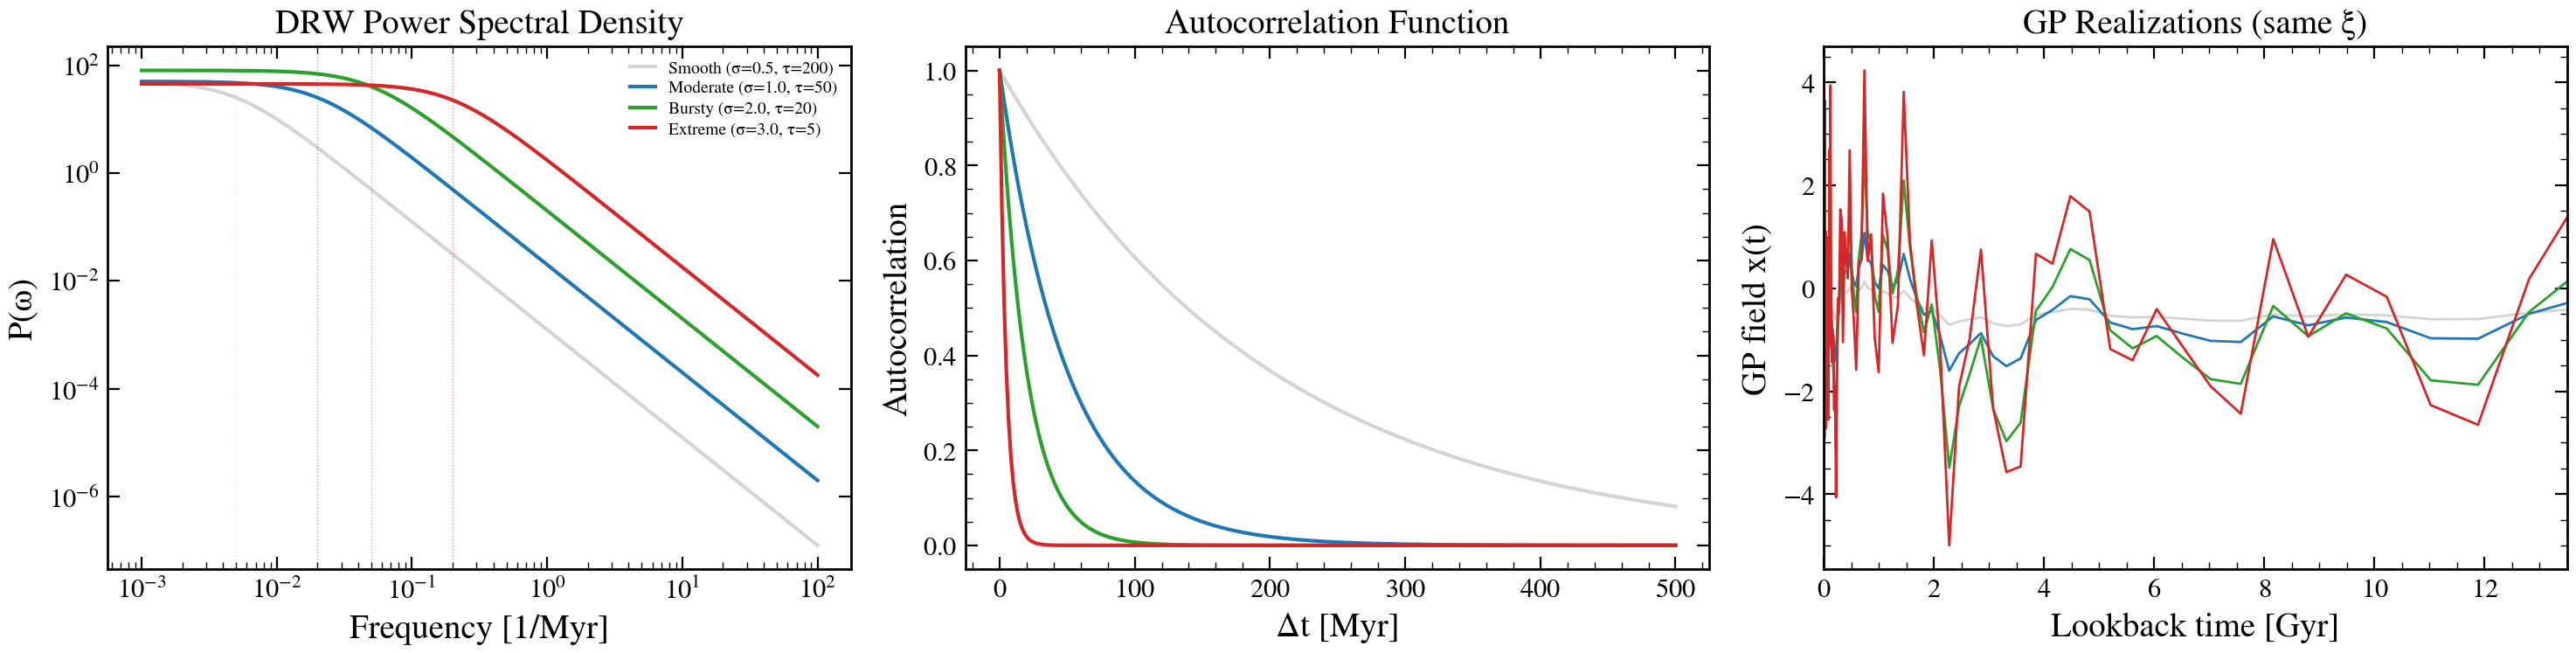

In [4]:
# --- FIGURE 1: DRW PSD for 4 regimes (3-panel) ---
omega = np.logspace(-3, 2, 500)  # frequency in 1/Myr

fig, (ax_psd, ax_acf, ax_gp) = plt.subplots(1, 3, figsize=(15, 4))

for reg in REGIMES:
    sigma, tau = reg["sigma"], reg["tau_myr"]
    # PSD
    P = sigma**2 * tau / (1 + (omega * tau) ** 2)
    ax_psd.loglog(omega, P, color=reg["color"], lw=1.5, label=reg["label"])
    # Break frequency
    ax_psd.axvline(1.0 / tau, color=reg["color"], ls=":", lw=0.5, alpha=0.5)

    # Autocorrelation
    dt = np.linspace(0, 500, 300)
    acf = np.exp(-dt / tau)
    ax_acf.plot(dt, acf, color=reg["color"], lw=1.5)

    # GP realization
    tau_yr = tau * 1e6
    sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_yr)
    xi = jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,))
    gp = gp_from_xi(xi, sqrt_power, N_GRID)
    ax_gp.plot(ages_gyr, np.array(gp), color=reg["color"], lw=1)

ax_psd.set_xlabel("Frequency [1/Myr]")
ax_psd.set_ylabel("P(ω)")
ax_psd.legend(fontsize=7)
ax_psd.set_title("DRW Power Spectral Density")

ax_acf.set_xlabel("Δt [Myr]")
ax_acf.set_ylabel("Autocorrelation")
ax_acf.set_title("Autocorrelation Function")

ax_gp.set_xlabel("Lookback time [Gyr]")
ax_gp.set_ylabel("GP field x(t)")
ax_gp.set_xlim(0, 13.5)
ax_gp.set_title("GP Realizations (same ξ)")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_psd_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

### What σ_PS and τ_PS Control

- **σ** controls amplitude — bigger σ means wilder swings in SFR.
- **τ** controls timescale — smaller τ means more rapid flickering.
Together they span the full range of SFH variability observed in galaxies.

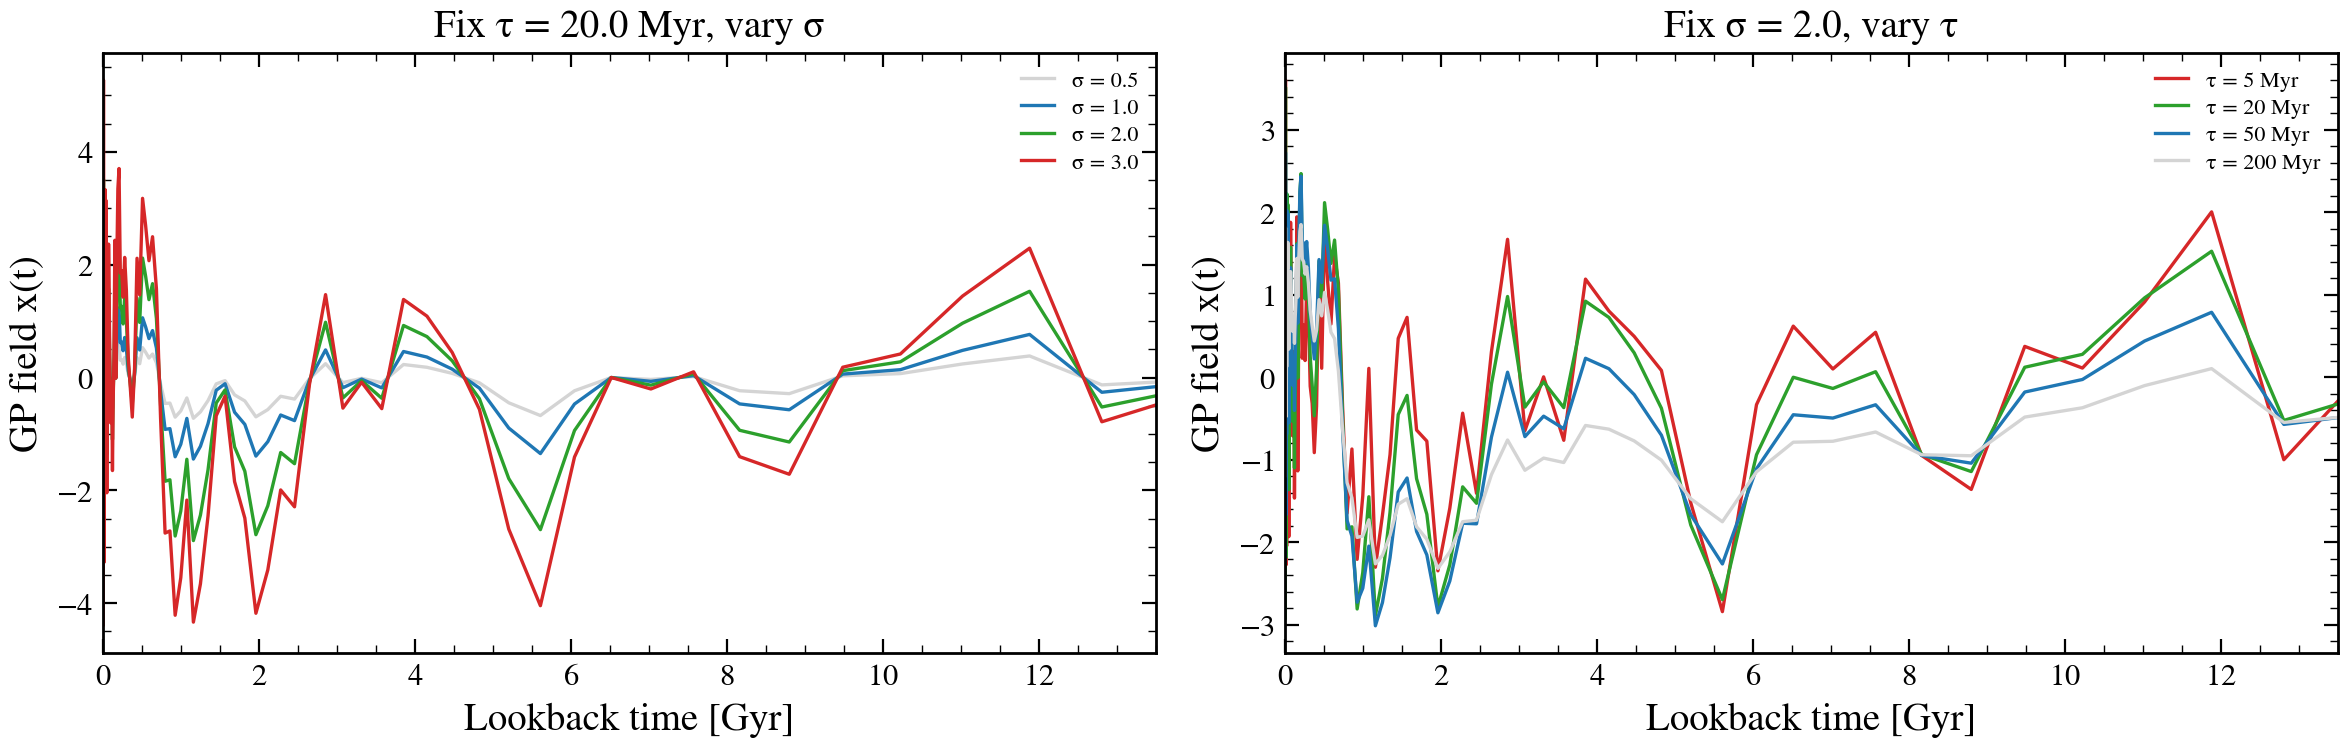

In [5]:
# --- FIGURE 2: Parameter sweeps ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# Fix τ = 20 Myr, sweep σ
tau_fixed = 20.0  # Myr
xi = jax.random.normal(jax.random.PRNGKey(7), shape=(N_GRID,))
for sigma, c in [
    (0.5, COLORS["seq"][0]),
    (1.0, COLORS["seq"][2]),
    (2.0, COLORS["seq"][3]),
    (3.0, COLORS["seq"][4]),
]:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_fixed * 1e6)
    gp = gp_from_xi(xi, sqrt_p, N_GRID)
    ax_sig.plot(ages_gyr, np.array(gp), color=c, lw=1.2, label=f"σ = {sigma}")
ax_sig.set_xlim(0, 13.5)
ax_sig.set_xlabel("Lookback time [Gyr]")
ax_sig.set_ylabel("GP field x(t)")
ax_sig.set_title(f"Fix τ = {tau_fixed} Myr, vary σ")
ax_sig.legend(fontsize=8)

# Fix σ = 2.0, sweep τ
sigma_fixed = 2.0
for tau, c in [
    (5, COLORS["seq"][4]),
    (20, COLORS["seq"][3]),
    (50, COLORS["seq"][2]),
    (200, COLORS["seq"][0]),
]:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_fixed, tau * 1e6)
    gp = gp_from_xi(xi, sqrt_p, N_GRID)
    ax_tau.plot(ages_gyr, np.array(gp), color=c, lw=1.2, label=f"τ = {tau} Myr")
ax_tau.set_xlim(0, 13.5)
ax_tau.set_xlabel("Lookback time [Gyr]")
ax_tau.set_ylabel("GP field x(t)")
ax_tau.set_title(f"Fix σ = {sigma_fixed}, vary τ")
ax_tau.legend(fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_parameter_sweeps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Building an SFH from Scratch

The magic of standardization: start with uncorrelated Gaussian noise
ξ ~ N(0, I), filter with √P to get correlated field x(t), combine with
mean SFH. Let's do it step by step.

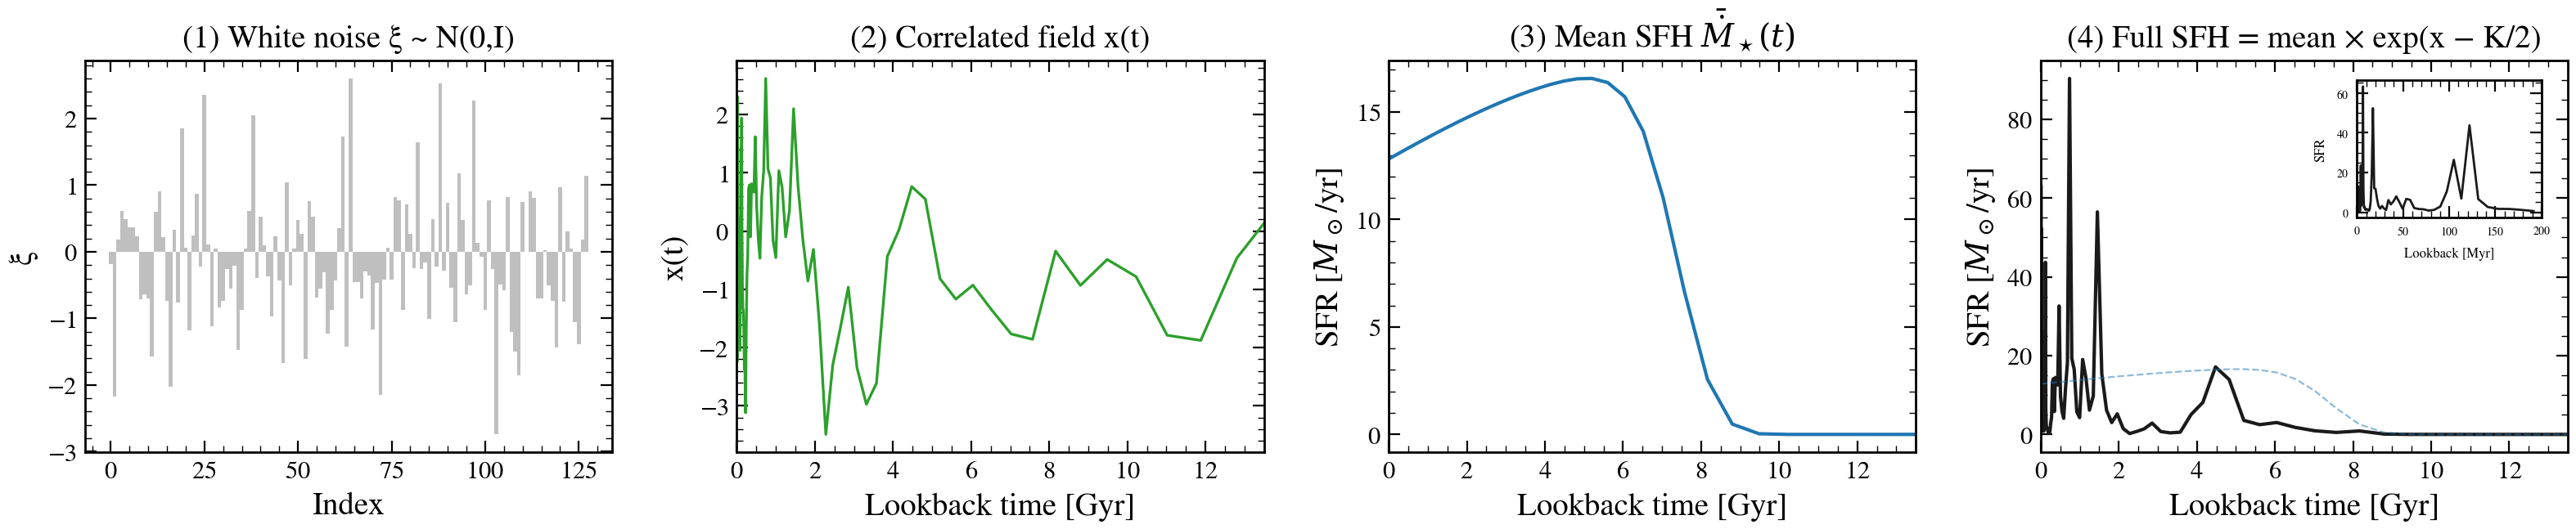

In [6]:
# --- FIGURE 3: Step-by-step assembly (1×4) ---
sigma, tau_myr = 2.0, 20.0
xi = jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,))
sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_myr * 1e6)
gp = gp_from_xi(xi, sqrt_power, N_GRID)

# Mean SFH (tsnorm)
mean_sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=2e9, skew=0.5, trunc=3.0)

# Full SFH
gp_np = np.array(gp)
variance = float(jnp.var(gp))
sfr_full = np.array(mean_sfr) * np.exp(gp_np - variance / 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

# (1) White noise ξ
axes[0].bar(range(N_GRID), np.array(xi), width=1, color="grey", alpha=0.5)
axes[0].set_xlabel("Index")
axes[0].set_ylabel("ξ")
axes[0].set_title("(1) White noise ξ ~ N(0,I)")

# (2) Correlated field x(t)
axes[1].plot(ages_gyr, gp_np, color=COLORS["sfh_gp"], lw=1.2)
axes[1].set_xlabel("Lookback time [Gyr]")
axes[1].set_ylabel("x(t)")
axes[1].set_xlim(0, 13.5)
axes[1].set_title("(2) Correlated field x(t)")

# (3) Mean SFH
axes[2].plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=1.5)
axes[2].set_xlabel("Lookback time [Gyr]")
axes[2].set_ylabel(r"SFR [$M_\odot$/yr]")
axes[2].set_xlim(0, 13.5)
axes[2].set_title(r"(3) Mean SFH $\bar{\dot{M}}_\star(t)$")

# (4) Full SFH
axes[3].plot(ages_gyr, sfr_full, color=COLORS["truth"], lw=1.5)
axes[3].plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
axes[3].set_xlabel("Lookback time [Gyr]")
axes[3].set_ylabel(r"SFR [$M_\odot$/yr]")
axes[3].set_xlim(0, 13.5)
axes[3].set_title("(4) Full SFH = mean × exp(x − K/2)")
# 200 Myr inset
inset = axes[3].inset_axes([0.6, 0.6, 0.35, 0.35])
mask_200 = ages_gyr < 0.2
if hasattr(ages_gyr, "__len__") and np.any(mask_200):
    inset.plot(ages_gyr[mask_200] * 1e3, sfr_full[mask_200], color=COLORS["truth"], lw=1)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_step_by_step.png"), dpi=150, bbox_inches="tight")
plt.show()

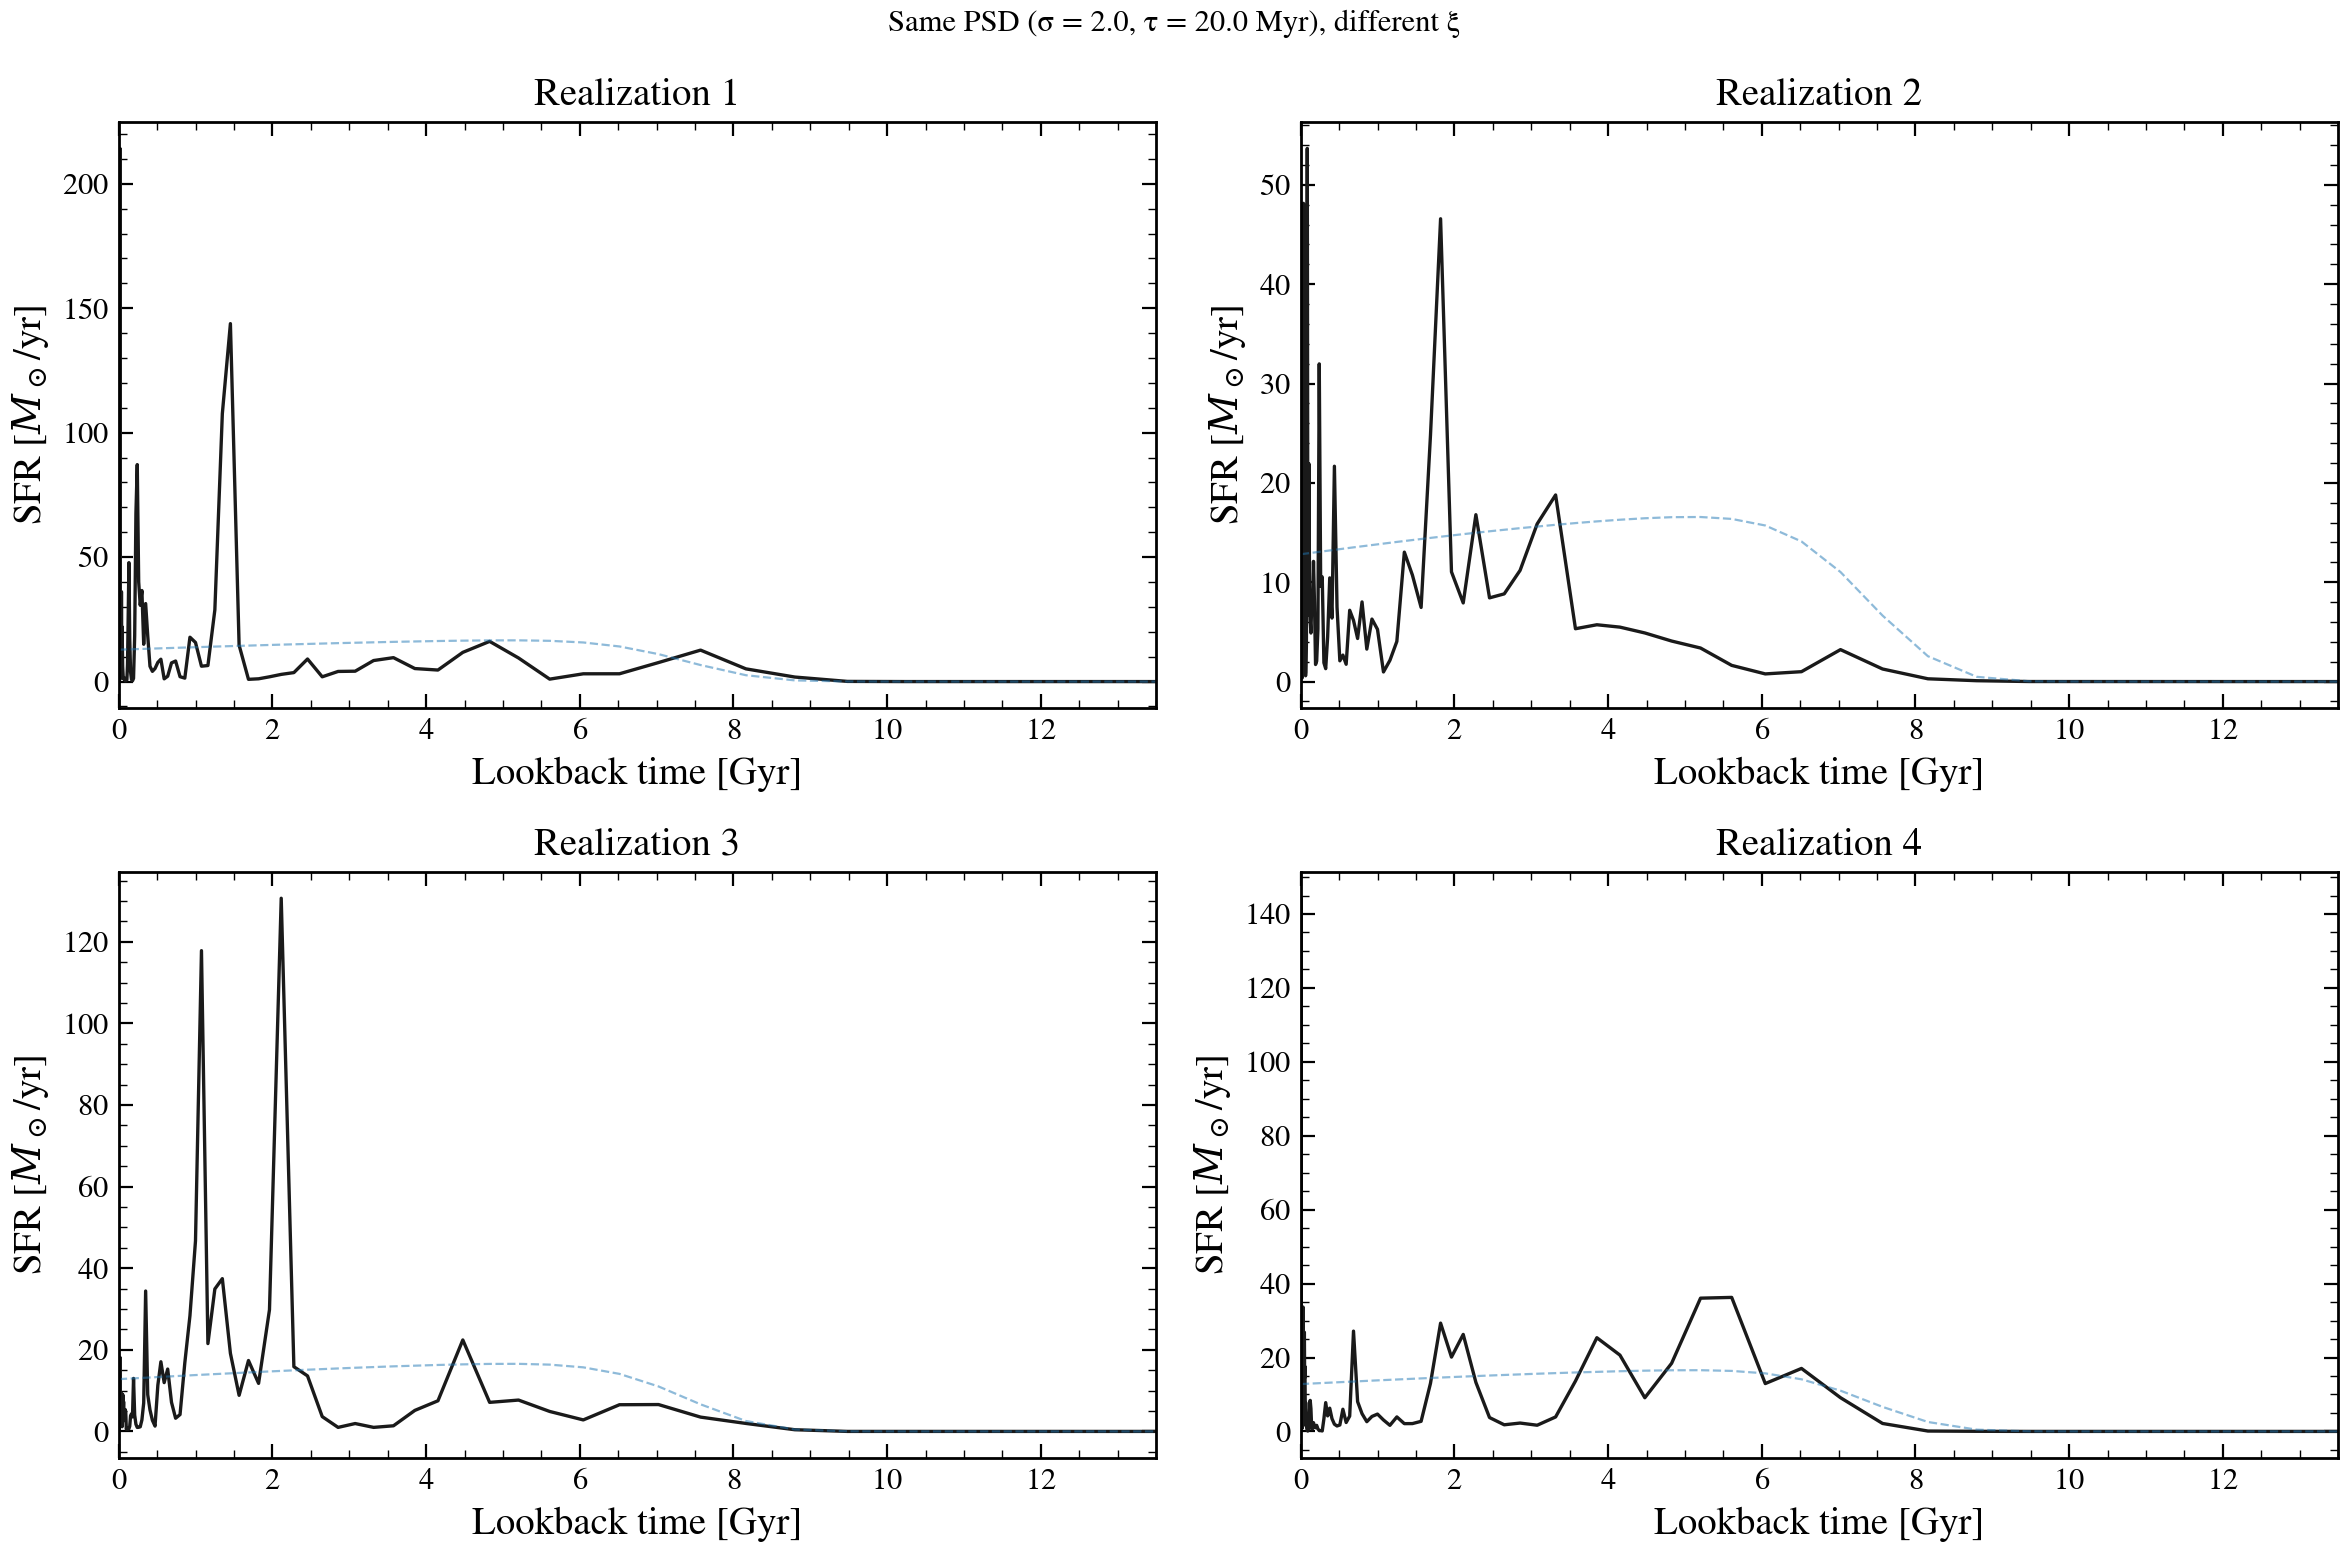

In [7]:
# --- FIGURE 4: Multiple realizations (2×2, same PSD) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, ax in enumerate(axes.flat):
    xi_i = jax.random.normal(jax.random.PRNGKey(idx * 7 + 3), shape=(N_GRID,))
    gp_i = np.array(gp_from_xi(xi_i, sqrt_power, N_GRID))
    sfr_i = np.array(mean_sfr) * np.exp(gp_i - variance / 2)
    ax.plot(ages_gyr, sfr_i, color=COLORS["truth"], lw=1.2)
    ax.plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")
    ax.set_title(f"Realization {idx + 1}")
fig.suptitle(f"Same PSD (σ = {sigma}, τ = {tau_myr} Myr), different ξ", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_multiple_realizations.png"), dpi=150, bbox_inches="tight")
plt.show()

### The Lognormal Correction

The −K(0)/2 term ensures E[SFR] = mean SFR regardless of GP amplitude.
Without it, a zero-mean Gaussian in log-space would bias the linear-space
average upward.

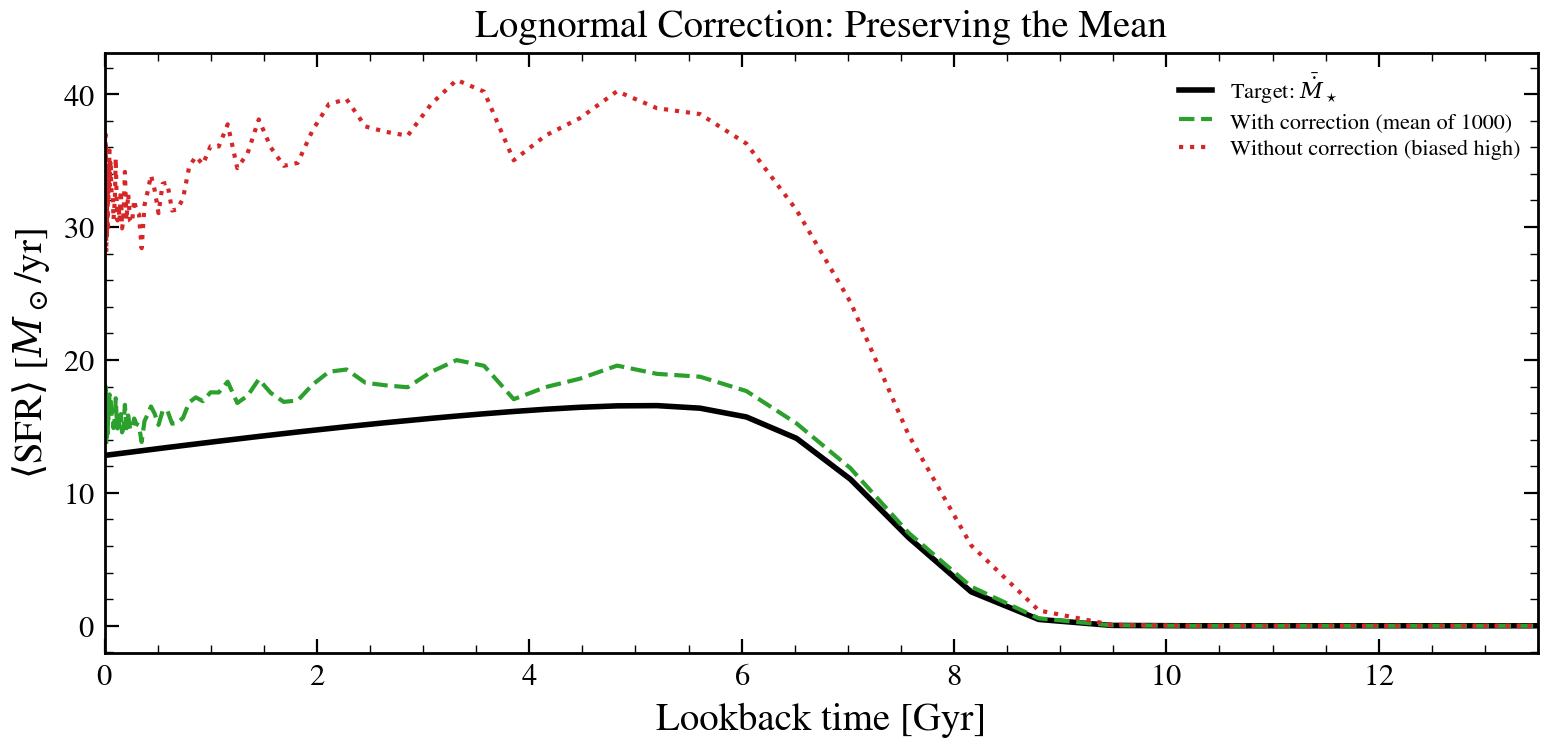

In [8]:
# --- FIGURE 5: With vs without correction ---
n_draws = 1000
sfr_with = []
sfr_without = []
for i in range(n_draws):
    xi_i = jax.random.normal(jax.random.PRNGKey(i), shape=(N_GRID,))
    gp_i = np.array(gp_from_xi(xi_i, sqrt_power, N_GRID))
    sfr_with.append(np.array(mean_sfr) * np.exp(gp_i - variance / 2))
    sfr_without.append(np.array(mean_sfr) * np.exp(gp_i))

mean_with = np.mean(sfr_with, axis=0)
mean_without = np.mean(sfr_without, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages_gyr, np.array(mean_sfr), "k-", lw=2, label=r"Target: $\bar{\dot{M}}_\star$")
ax.plot(
    ages_gyr,
    mean_with,
    color=COLORS["sfh_gp"],
    lw=1.5,
    ls="--",
    label=f"With correction (mean of {n_draws})",
)
ax.plot(
    ages_gyr,
    mean_without,
    color=COLORS["model"],
    lw=1.5,
    ls=":",
    label="Without correction (biased high)",
)
ax.set_xlim(0, 13.5)
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"$\langle$SFR$\rangle$ [$M_\odot$/yr]")
ax.legend(fontsize=8)
ax.set_title("Lognormal Correction: Preserving the Mean")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_lognormal_correction.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. The Secular Backbone

The GP has zero mean by construction, so we need a separate smooth secular
component. tengri supports 8 parametric shapes (plus tabulated). The
default is the truncated skew-normal (tsnorm, Bellstedt+2020).

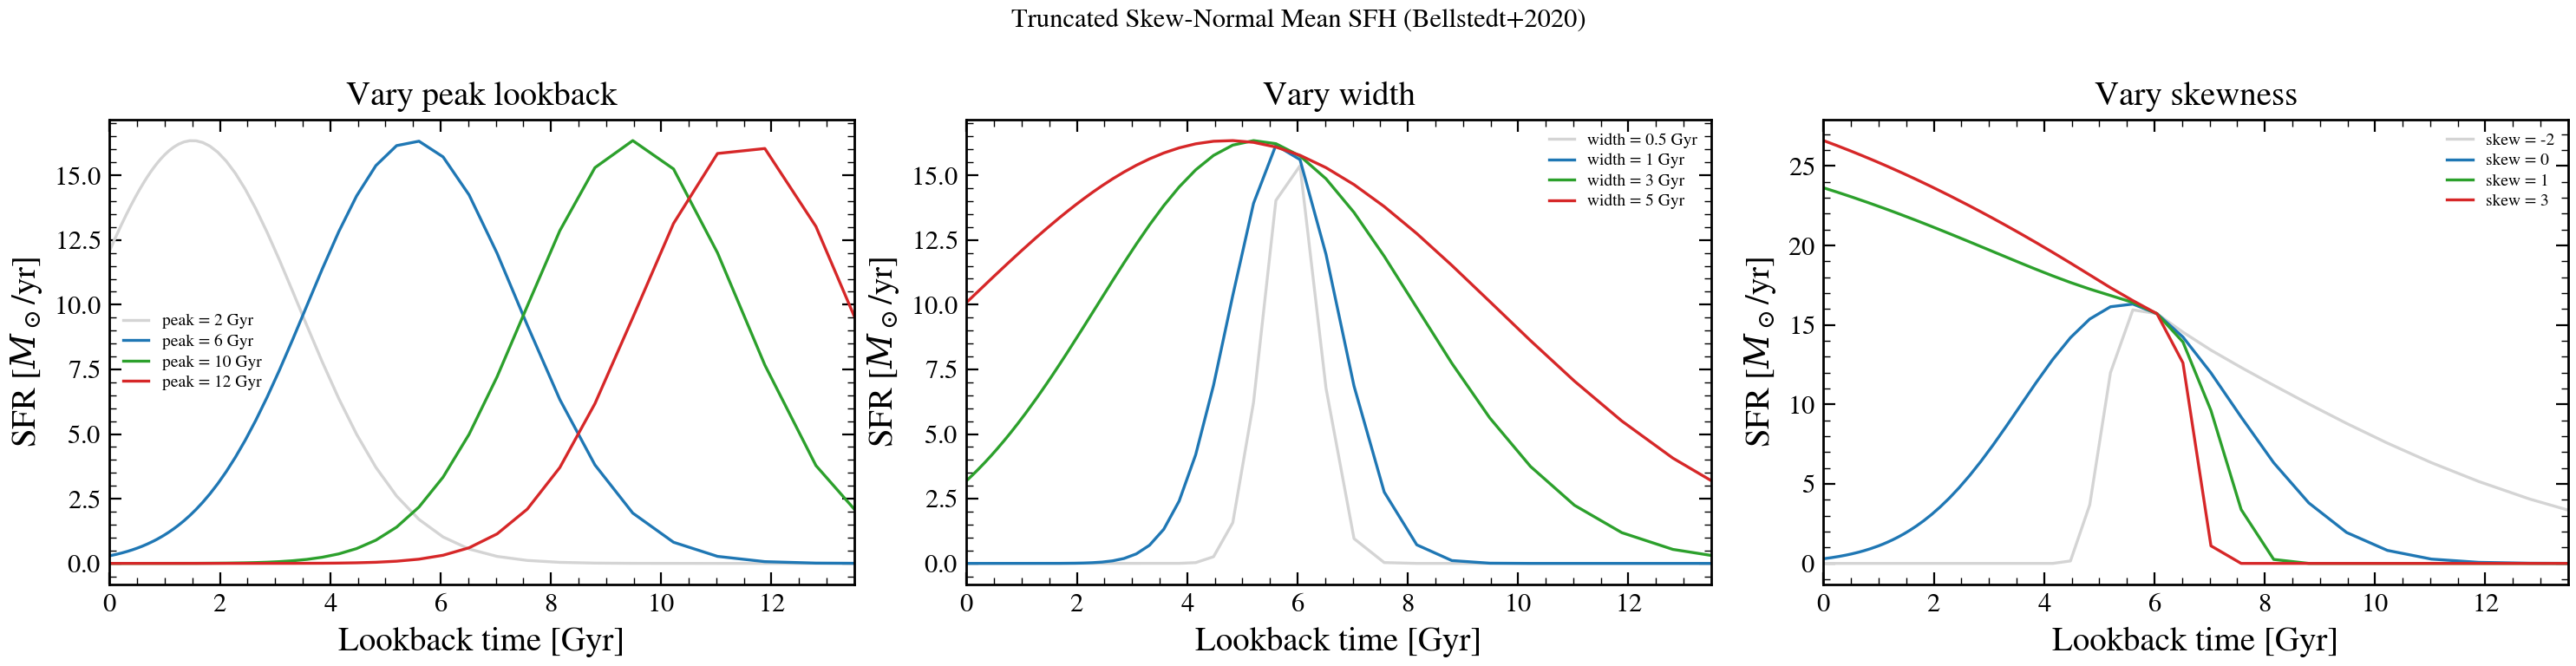

In [9]:
# --- FIGURE 6: tsnorm variations ---
fig, (ax_lbt, ax_w, ax_s) = plt.subplots(1, 3, figsize=(15, 4))

# Vary peak lookback
for lbt, c in [
    (2, COLORS["seq"][0]),
    (6, COLORS["seq"][2]),
    (10, COLORS["seq"][3]),
    (12, COLORS["seq"][4]),
]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=lbt * 1e9, width=2e9, skew=0.0, trunc=3.0)
    ax_lbt.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"peak = {lbt} Gyr")
ax_lbt.set_xlim(0, 13.5)
ax_lbt.legend(fontsize=7)
ax_lbt.set_title("Vary peak lookback")

# Vary width
for w, c in [
    (0.5, COLORS["seq"][0]),
    (1, COLORS["seq"][2]),
    (3, COLORS["seq"][3]),
    (5, COLORS["seq"][4]),
]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=w * 1e9, skew=0.0, trunc=3.0)
    ax_w.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"width = {w} Gyr")
ax_w.set_xlim(0, 13.5)
ax_w.legend(fontsize=7)
ax_w.set_title("Vary width")

# Vary skew
for s, c in [
    (-2, COLORS["seq"][0]),
    (0, COLORS["seq"][2]),
    (1, COLORS["seq"][3]),
    (3, COLORS["seq"][4]),
]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=2e9, skew=float(s), trunc=3.0)
    ax_s.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"skew = {s}")
ax_s.set_xlim(0, 13.5)
ax_s.legend(fontsize=7)
ax_s.set_title("Vary skewness")

for ax in [ax_lbt, ax_w, ax_s]:
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")

fig.suptitle("Truncated Skew-Normal Mean SFH (Bellstedt+2020)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_tsnorm_variations.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. The Burstiness Plane

The (σ, τ) parameter space spans the full range of SFH variability.

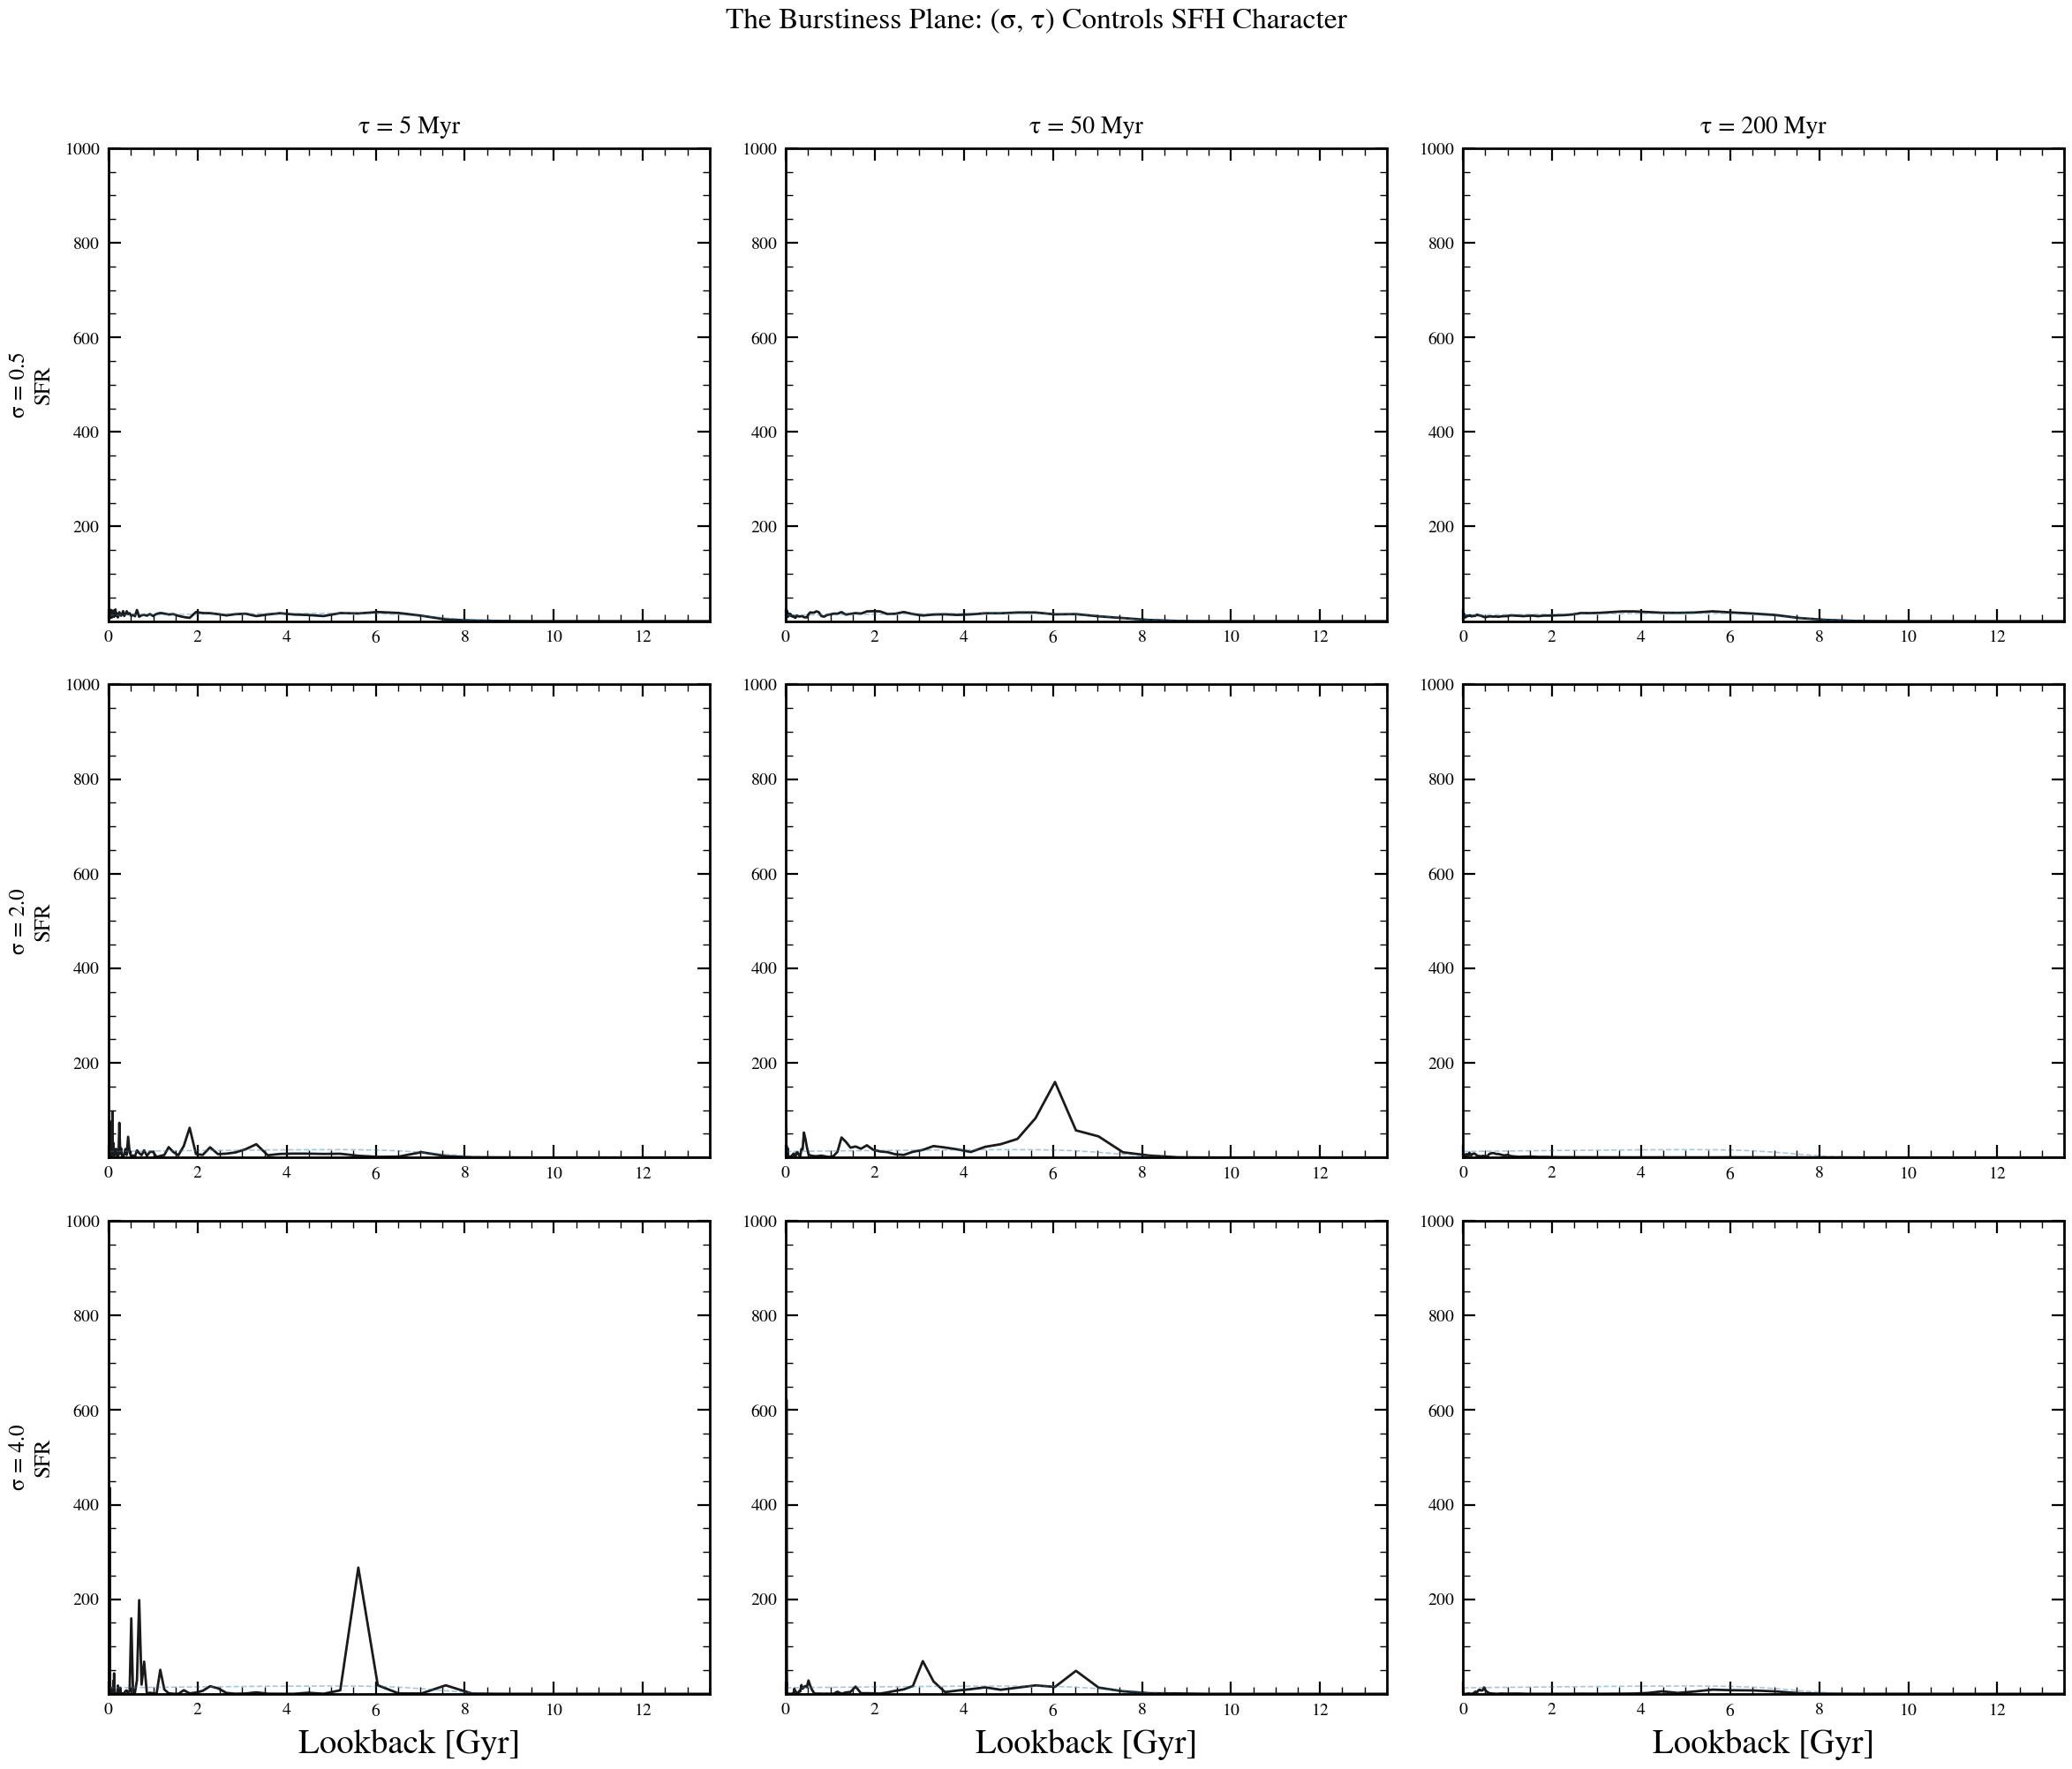

In [10]:
# --- FIGURE 7: 3×3 burstiness plane ---
sigmas = [0.5, 2.0, 4.0]
taus = [5, 50, 200]  # Myr

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, sigma in enumerate(sigmas):
    for j, tau in enumerate(taus):
        ax = axes[i, j]
        sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau * 1e6)
        xi_ij = jax.random.normal(jax.random.PRNGKey(i * 10 + j), shape=(N_GRID,))
        gp_ij = np.array(gp_from_xi(xi_ij, sqrt_p, N_GRID))
        var_ij = float(
            jnp.var(
                gp_from_xi(
                    jax.random.normal(jax.random.PRNGKey(999), shape=(N_GRID,)), sqrt_p, N_GRID
                )
            )
        )
        sfr_ij = np.array(mean_sfr) * np.exp(gp_ij - var_ij / 2)

        ax.plot(ages_gyr, sfr_ij, color=COLORS["truth"], lw=1)
        ax.plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=0.6, ls="--", alpha=0.4)
        ax.set_xlim(0, 13.5)
        ax.set_ylim(1e-2, 1e3)

        if i == 0:
            ax.set_title(f"τ = {tau} Myr", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"σ = {sigma}\nSFR", fontsize=9)
        if i == 2:
            ax.set_xlabel("Lookback [Gyr]")
        ax.tick_params(labelsize=7)

fig.suptitle("The Burstiness Plane: (σ, τ) Controls SFH Character", fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig07_burstiness_plane.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Observable Connection

Different spectral tracers average over different lookback timescales:
Hα ~ few Myr, UV ~ 10–100 Myr, Balmer break ~ 100 Myr – 1 Gyr. The PSD
language makes this precise.

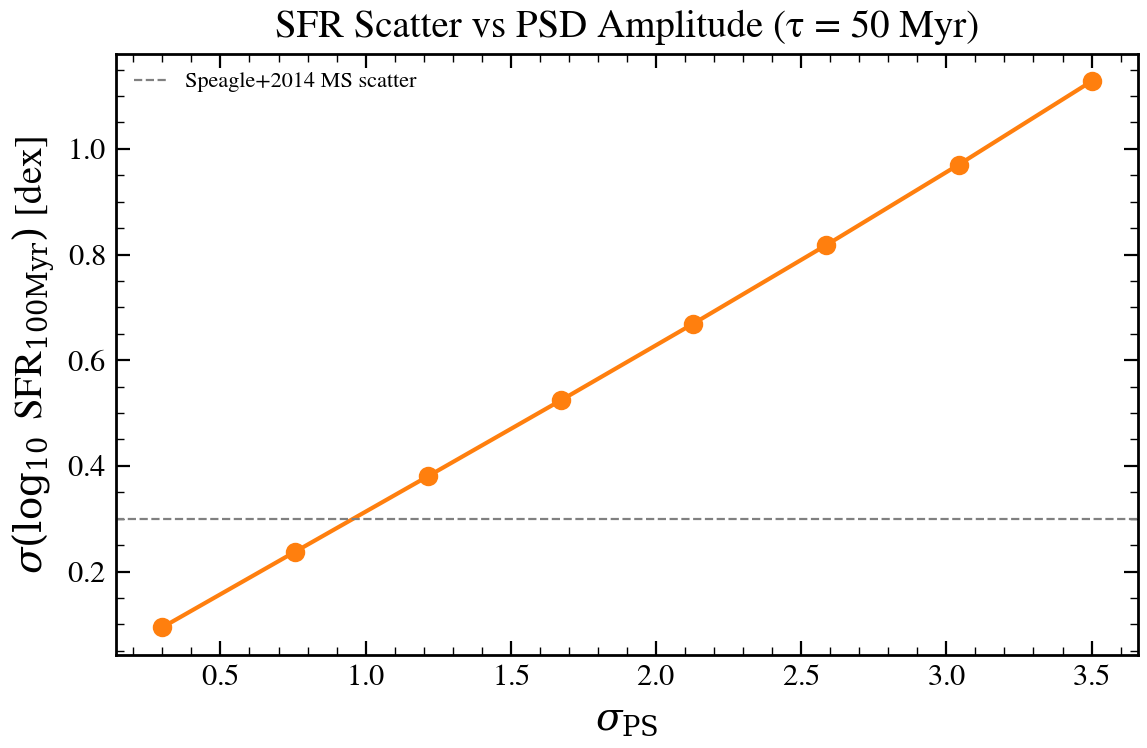

In [11]:
# --- FIGURE 8: Observable diagnostics ---
n_ens = 200
sig_range = np.linspace(0.3, 3.5, 8)

sfr_scatter_100 = []
for sigma in sig_range:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, 50.0 * 1e6)
    sfrs_100 = []
    for k in range(n_ens):
        xi_k = jax.random.normal(jax.random.PRNGKey(k + 1000), shape=(N_GRID,))
        gp_k = np.array(gp_from_xi(xi_k, sqrt_p, N_GRID))
        sfr_k = np.array(mean_sfr) * np.exp(
            gp_k - float(jnp.var(gp_from_xi(xi_k, sqrt_p, N_GRID))) / 2
        )
        # SFR at 100 Myr lookback
        idx_100 = np.argmin(np.abs(ages_gyr - 0.1))
        sfrs_100.append(sfr_k[idx_100])
    sfr_scatter_100.append(np.std(np.log10(np.clip(sfrs_100, 1e-5, None))))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sig_range, sfr_scatter_100, "o-", color=COLORS["geovi"], lw=1.5)
ax.axhline(0.3, color="grey", ls="--", lw=0.8, label="Speagle+2014 MS scatter")
ax.set_xlabel(r"$\sigma_{\rm PS}$")
ax.set_ylabel(r"$\sigma(\log_{10}$ SFR$_{100\rm Myr})$ [dex]")
ax.legend(fontsize=8)
ax.set_title("SFR Scatter vs PSD Amplitude (τ = 50 Myr)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig08_observable_diagnostics.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Green's Functions and Window Functions

The Green's function $G_\lambda(t_{\rm age})$ is the luminosity produced by
$1\,M_\odot$ of stars formed at age $t_{\rm age}$, observed at wavelength
$\lambda$. It is simply the SSP SED evaluated at specific wavelengths as a
function of stellar age (Burnham+2026, arXiv:2601.20930). The observable
luminosity is a convolution:

$$L_\lambda(t_{\rm obs}) = \int G_\lambda(t_{\rm age}) \cdot
  \dot{M}_\star(t_{\rm age})\, dt_{\rm age}$$

Different wavelengths probe different SFH timescales:

- **H-alpha (6563 A):** peaks at ~3--5 Myr, drops by orders of magnitude by
  10 Myr. Traces star formation on ~5 Myr timescales.
- **FUV (1500 A):** peaks at ~10 Myr, decays over ~100 Myr. Traces star
  formation on ~50 Myr timescales.
- **Optical V-band (5500 A):** relatively flat with age. Traces accumulated
  stellar mass.
- **NIR H-band (1.6 um):** very flat. Excellent stellar mass tracer.

The Green's function determines what timescales each observable probes:
H-alpha is sensitive to PSD power at ~5 Myr (constrains short-timescale
burstiness), while UV averages over ~50 Myr (constrains intermediate
timescales). The H-alpha/UV ratio is therefore sensitive to the PSD slope
between 5--50 Myr.

In [12]:
from tengri import load_ssp_data

ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
from tengri.diagnostics.green_functions import (
    compute_green_function,
    compute_window_function,
)
from tengri.models.sps.dsps_wrapper import interpolate_metallicity

# Pick a reference metallicity (solar)
LOG10_ZSUN = -1.848
ssp_flux_at_z = interpolate_metallicity(ssp_data.ssp_flux, ssp_data.ssp_lgmet, LOG10_ZSUN)
ssp_ages_yr = 10.0 ** (ssp_data.ssp_lg_age_gyr + 9.0)
ssp_ages_myr = ssp_ages_yr / 1e6

# Key wavelengths (Burnham+2026 Fig. 2 style)
wavelengths_burnham = {
    r"H$\alpha$ (6563 $\AA$)": 6563.0,
    r"FUV (1500 $\AA$)": 1500.0,
    r"V-band (5500 $\AA$)": 5500.0,
    r"H-band (1.6 $\mu$m)": 16000.0,
}
colors_gf = {
    r"H$\alpha$ (6563 $\AA$)": "#7b2d8e",  # purple
    r"FUV (1500 $\AA$)": "#2ca02c",  # green
    r"V-band (5500 $\AA$)": "#d67d00",  # orange
    r"H-band (1.6 $\mu$m)": "#c44e52",  # red
}

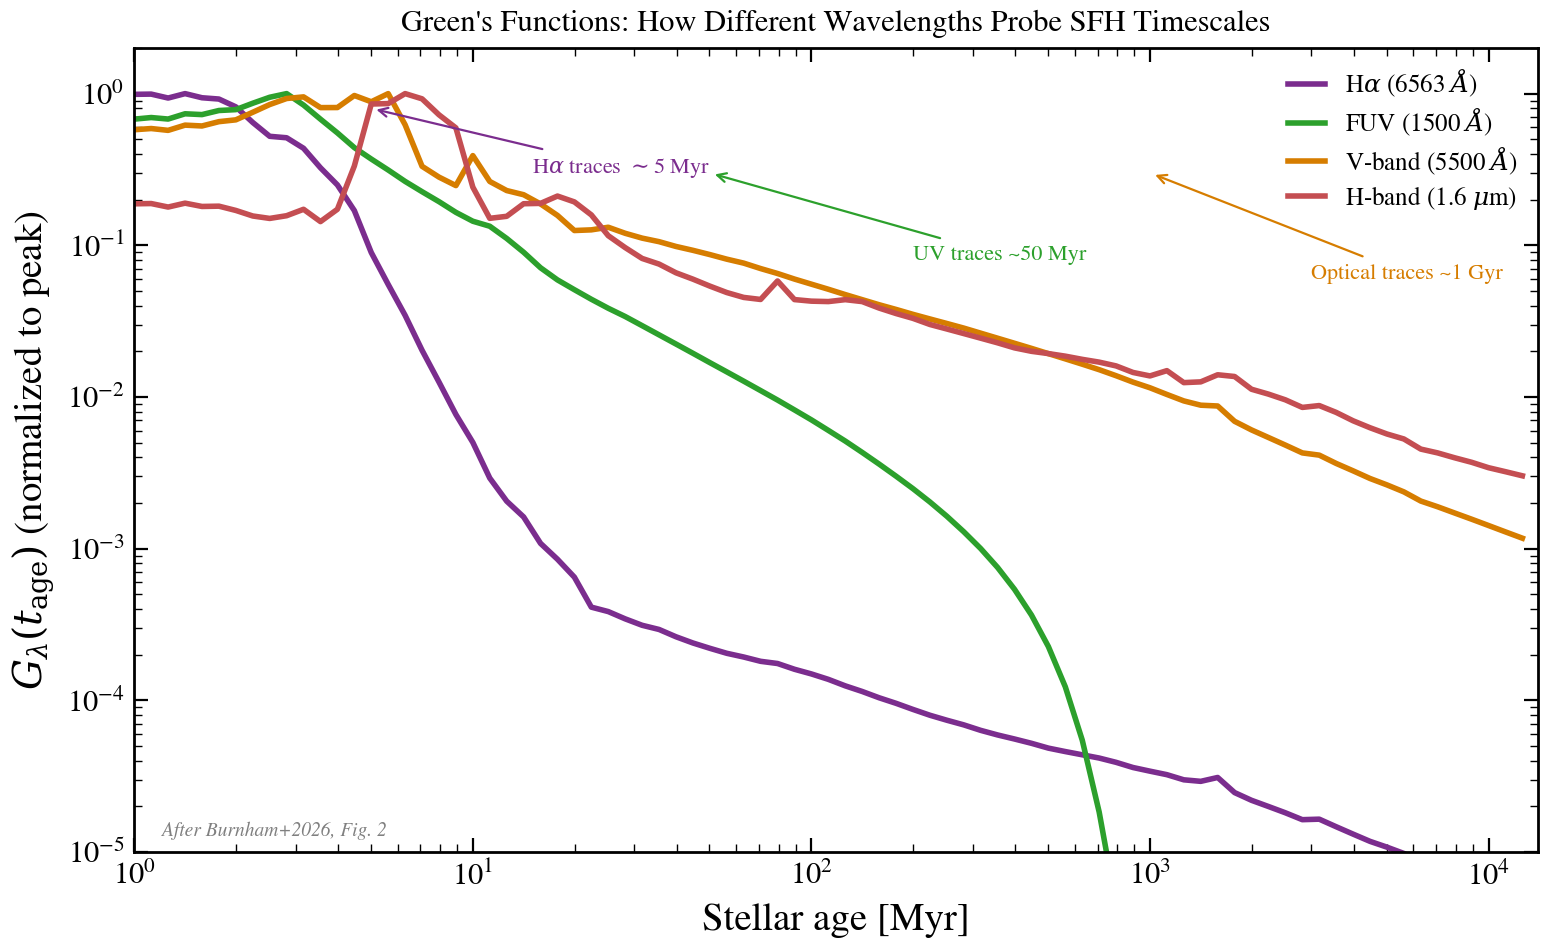

In [13]:
# --- FIGURE 4: Green's functions (Burnham+2026 style) ---
fig, ax = plt.subplots(figsize=(8, 5))

for label, wave in wavelengths_burnham.items():
    gf = compute_green_function(ssp_flux_at_z, ssp_data.ssp_wave, wave_target=wave)
    gf_norm = gf / jnp.max(gf)
    ax.plot(ssp_ages_myr, gf_norm, label=label, color=colors_gf[label], lw=2.0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar age [Myr]")
ax.set_ylabel(r"$G_\lambda(t_{\rm age})$ (normalized to peak)")
ax.set_title(
    r"Green's Functions: How Different Wavelengths Probe SFH Timescales",
    fontsize=11,
)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.set_xlim(1, 14000)
ax.set_ylim(1e-5, 2.0)

# Annotate characteristic timescales
ax.annotate(
    r"H$\alpha$ traces $\sim$5 Myr",
    xy=(5, 0.8),
    xytext=(15, 0.3),
    fontsize=8,
    color="#7b2d8e",
    arrowprops={"arrowstyle": "->", "color": "#7b2d8e", "lw": 0.8},
)
ax.annotate(
    "UV traces ~50 Myr",
    xy=(50, 0.3),
    xytext=(200, 0.08),
    fontsize=8,
    color="#2ca02c",
    arrowprops={"arrowstyle": "->", "color": "#2ca02c", "lw": 0.8},
)
ax.annotate(
    "Optical traces ~1 Gyr",
    xy=(1000, 0.3),
    xytext=(3000, 0.06),
    fontsize=8,
    color="#d67d00",
    arrowprops={"arrowstyle": "->", "color": "#d67d00", "lw": 0.8},
)

# Reference note
ax.text(
    0.02,
    0.02,
    "After Burnham+2026, Fig. 2",
    transform=ax.transAxes,
    fontsize=7,
    fontstyle="italic",
    color="gray",
)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_green_functions.png"), bbox_inches="tight")
plt.show()

### Window Functions

The window function $W_\lambda(t) = G_\lambda(t) \cdot \langle \text{SFR}(t)
\rangle$ weights the Green's function by the mean SFH. While $G_\lambda$
tells you what ages a wavelength *can* probe, the window function tells you
which lookback times *actually* contribute to the observed flux for a given
galaxy. A wavelength that is sensitive to 10 Myr ages is useless if the
galaxy had no star formation 10 Myr ago.

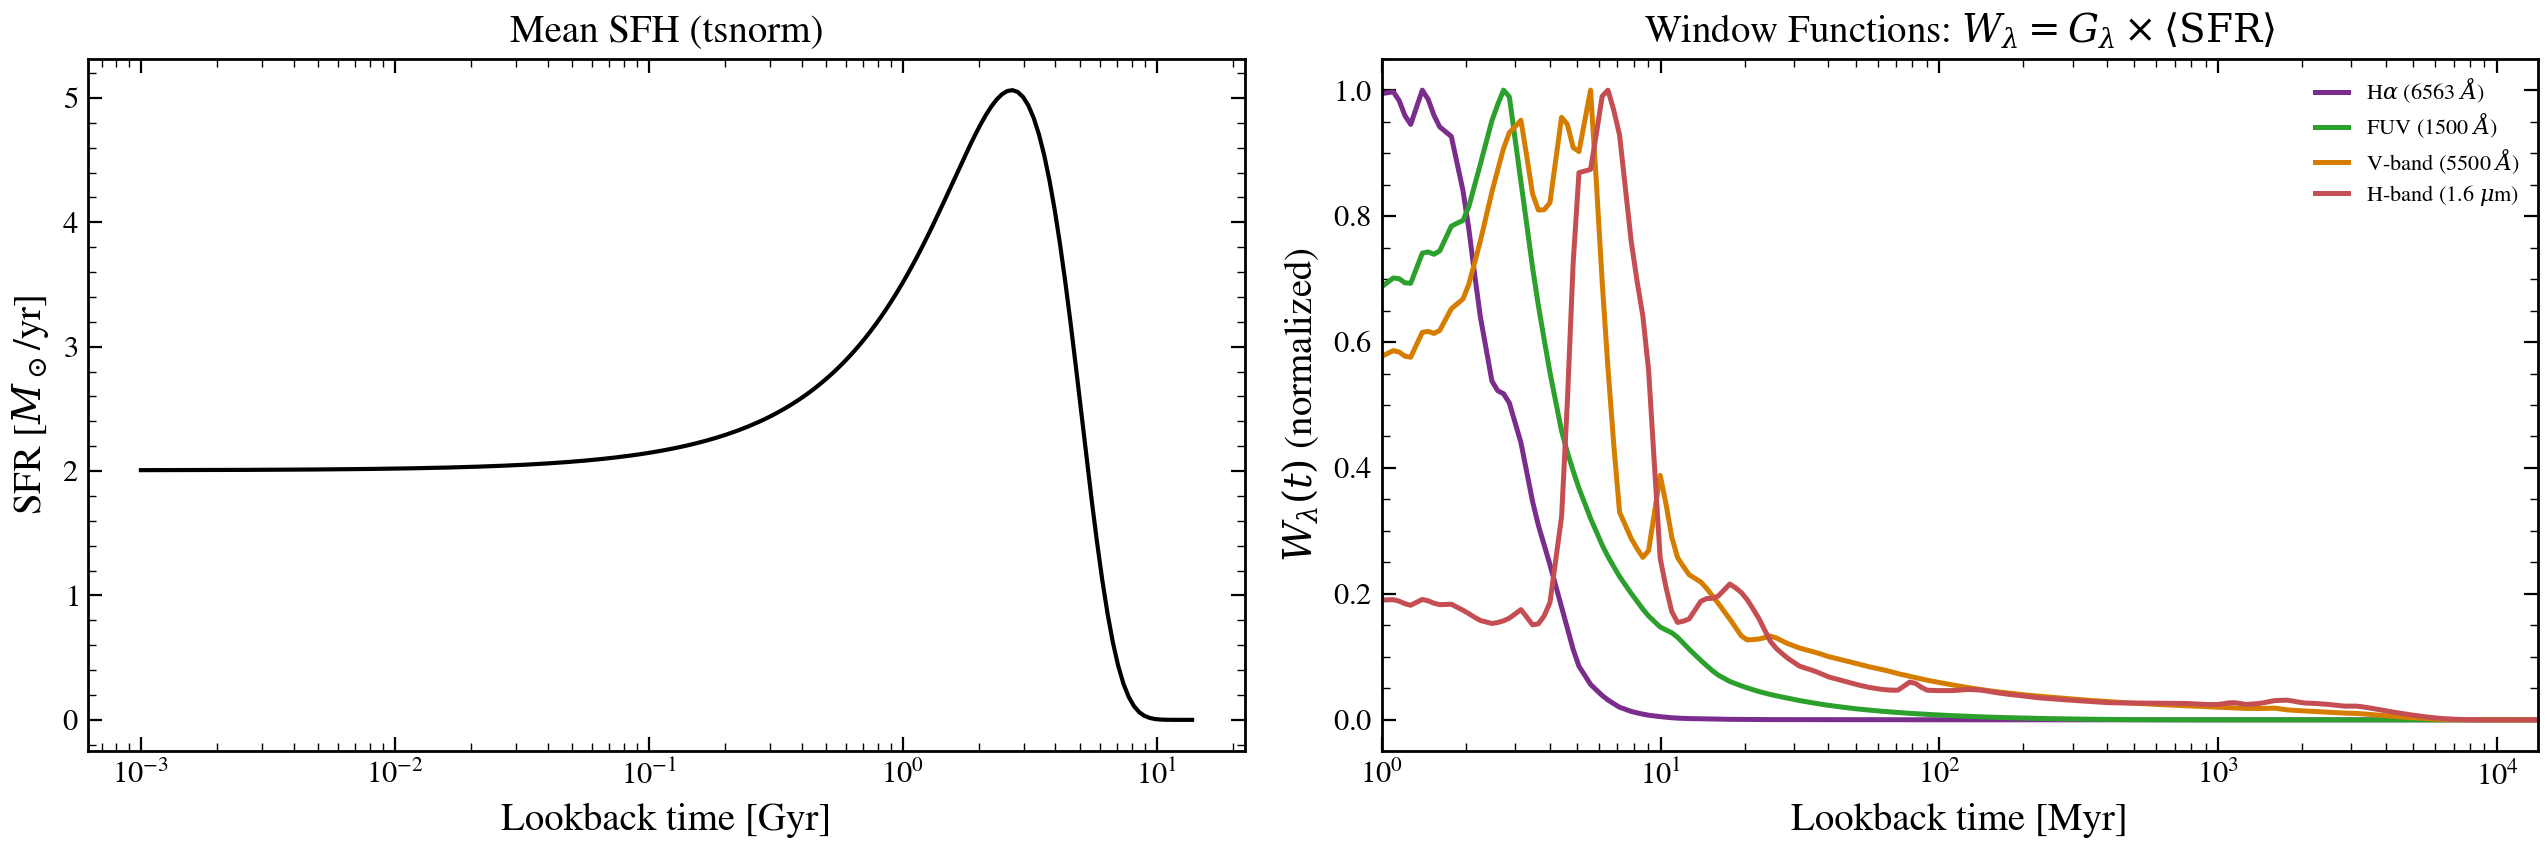

In [14]:
# --- FIGURE 5: Window functions with a tsnorm mean SFH ---
ages_yr_grid = jnp.logspace(6, 10.14, 200)
mean_sfr = tsnorm(ages_yr_grid, log_peak_sfr=1.0, peak_lbt=3e9, width=2e9, skew=0.0, trunc=5.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: mean SFH
ax = axes[0]
ax.plot(ages_yr_grid / 1e9, mean_sfr, "k-", lw=1.5)
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("SFR [$M_\\odot$/yr]")
ax.set_title("Mean SFH (tsnorm)")
ax.set_xscale("log")

# Right: window functions
ax = axes[1]
for label, wave in wavelengths_burnham.items():
    gf = compute_green_function(ssp_flux_at_z, ssp_data.ssp_wave, wave_target=wave)
    # Interpolate GF onto the same age grid
    gf_interp = jnp.interp(jnp.log10(ages_yr_grid), jnp.log10(ssp_ages_yr), gf)
    wf = compute_window_function(gf_interp, mean_sfr)
    wf_norm = wf / jnp.max(wf + 1e-30)
    ax.plot(ages_yr_grid / 1e6, wf_norm, label=label, color=colors_gf[label], lw=1.8)
ax.set_xscale("log")
ax.set_xlabel("Lookback time [Myr]")
ax.set_ylabel(r"$W_\lambda(t)$ (normalized)")
ax.set_title(r"Window Functions: $W_\lambda = G_\lambda \times \langle \mathrm{SFR} \rangle$")
ax.legend(fontsize=8, frameon=False)
ax.set_xlim(1, 14000)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_window_functions.png"), bbox_inches="tight")
plt.show()

### Connecting Green's Functions to PSD Inference

The Green's function is the bridge between PSD parameters and observables:

1. **H-alpha probes ~5 Myr timescales** — it is sensitive to PSD power at
   $\omega \sim 2\pi / (5\,\text{Myr})$, constraining short-timescale
   burstiness ($\sigma_{\rm PS}$).

2. **UV probes ~50 Myr timescales** — it averages over the most recent
   ~50 Myr of star formation, constraining intermediate PSD power.

3. **The H-alpha/UV ratio is sensitive to the PSD slope** between 5 and
   50 Myr — a steep PSD (low short-timescale power) gives a tight
   H-alpha/UV relation, while a flat PSD (high burstiness at all
   timescales) produces large scatter.

4. **Optical/NIR constrain the long-timescale SFH** (stellar mass
   buildup) but are insensitive to the PSD — their Green's functions
   are nearly flat with age.

This is why photometric SED fitting with only broadband data struggles
to constrain burstiness: the observations average over too many
timescales. Adding H-alpha (or spectroscopy near H-alpha) dramatically
improves PSD constraints because it provides a narrow time probe.

## 7. Observable Diagnostics

The PSD parameters leave imprints on observable diagnostics. Higher $\sigma$
increases the scatter in sSFR and Ha/UV ratio at fixed stellar mass.

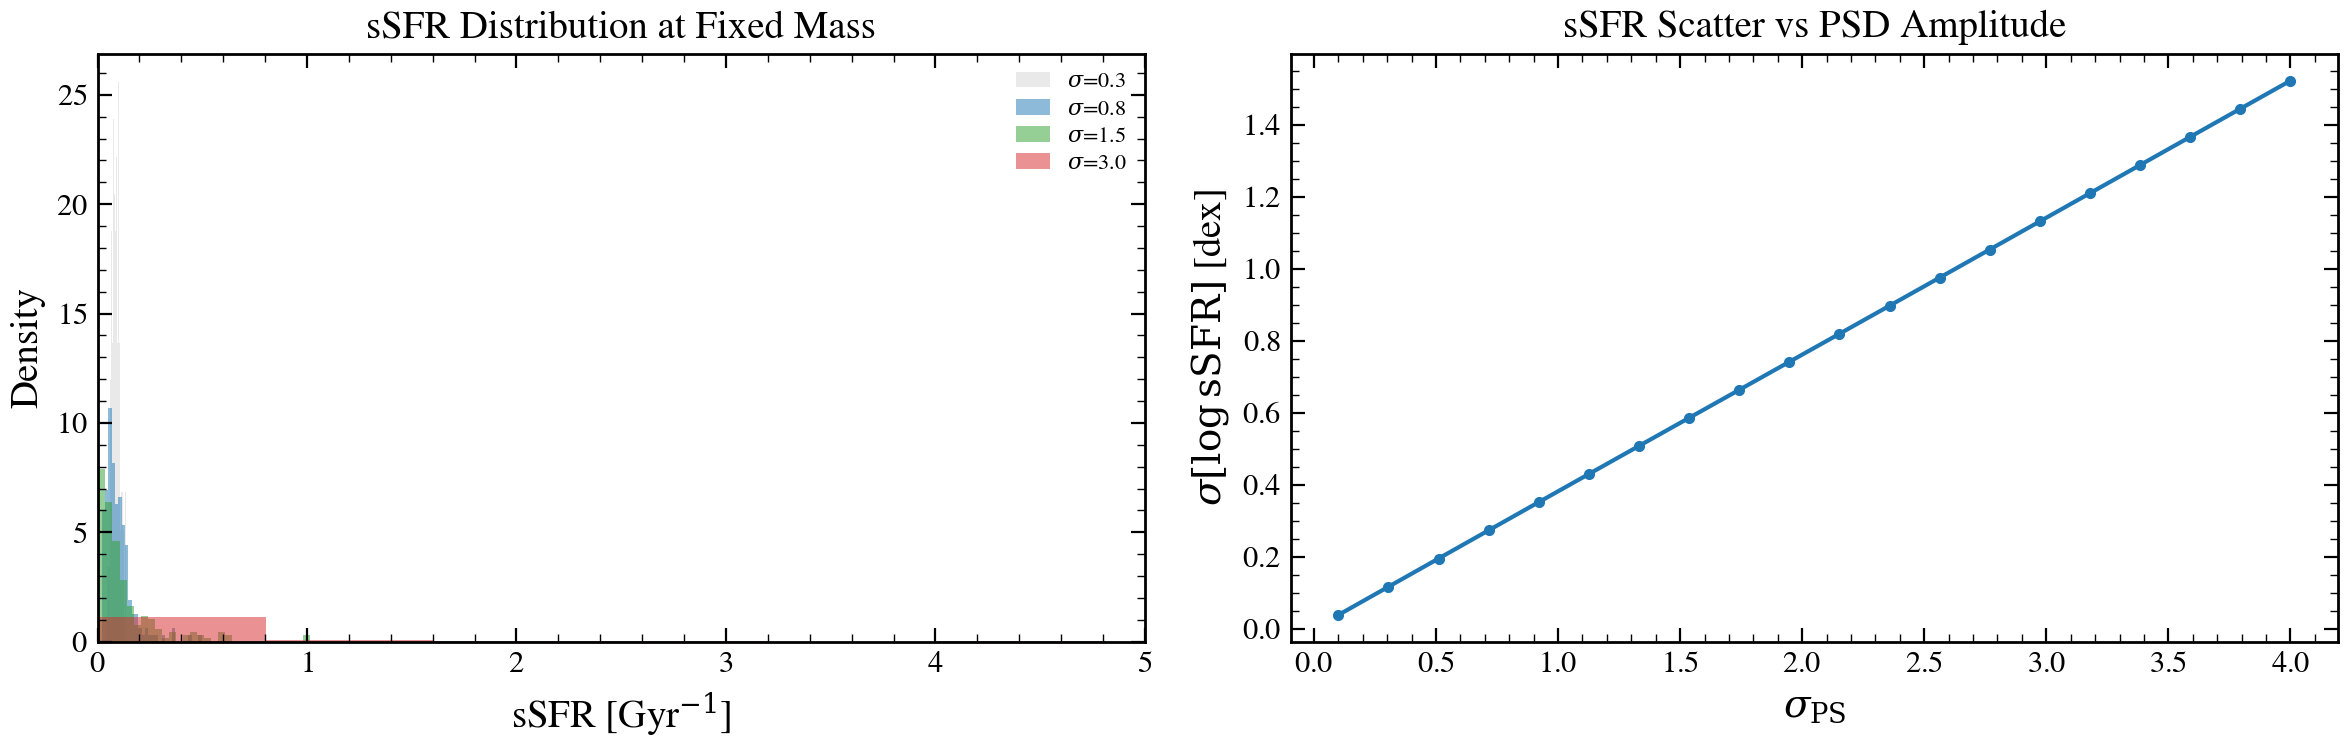

In [15]:
# --- FIGURE 6: sSFR scatter as a function of sigma_PS ---
key = jax.random.PRNGKey(0)
n_samples = 200
sigma_values = [0.3, 0.8, 1.5, 3.0]
tau_myr_fixed = 100.0
tau_yr_fixed = tau_myr_fixed * 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, sigma in enumerate(sigma_values):
    ssfr_samples = []
    ha_uv_samples = []
    for i in range(n_samples):
        subkey = jax.random.fold_in(key, i + idx * 1000)
        sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_yr_fixed)
        gp = generate_gp_fourier(subkey, sqrt_p, N_GRID)
        # Mean SFH
        base_sfr = tsnorm(
            10**log_ages,
            log_peak_sfr=1.0,
            peak_lbt=3e9,
            width=2e9,
            skew=0.0,
            trunc=5.0,
        )
        # Full SFH with lognormal correction
        var_x = drw_variance(sigma)
        full_sfr = base_sfr * jnp.exp(gp - var_x)
        # sSFR = SFR(recent) / integral(SFR)
        recent_sfr = float(jnp.mean(full_sfr[:5]))
        total_mass = float(jnp.trapezoid(full_sfr, 10**log_ages))
        if total_mass > 0:
            ssfr_samples.append(recent_sfr / total_mass * 1e9)  # per Gyr
    axes[0].hist(
        ssfr_samples,
        bins=30,
        alpha=0.5,
        density=True,
        color=REGIMES[idx]["color"],
        label=f"$\\sigma$={sigma}",
    )

axes[0].set_xlabel("sSFR [Gyr$^{-1}$]")
axes[0].set_ylabel("Density")
axes[0].set_title("sSFR Distribution at Fixed Mass")
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_xlim(0, 5)

# Panel 2: scatter in log(sSFR) vs sigma
sigma_range = np.linspace(0.1, 4.0, 20)
scatter_vals = []
for sigma_val in sigma_range:
    ssfrs = []
    for i in range(100):
        subkey = jax.random.fold_in(key, i + 10000)
        sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, float(sigma_val), tau_yr_fixed)
        gp = generate_gp_fourier(subkey, sqrt_p, N_GRID)
        base_sfr = tsnorm(
            10**log_ages,
            log_peak_sfr=1.0,
            peak_lbt=3e9,
            width=2e9,
            skew=0.0,
            trunc=5.0,
        )
        var_x = drw_variance(float(sigma_val))
        full_sfr = base_sfr * jnp.exp(gp - var_x)
        recent = float(jnp.mean(full_sfr[:5]))
        total = float(jnp.trapezoid(full_sfr, 10**log_ages))
        if total > 0:
            ssfrs.append(np.log10(max(recent / total * 1e9, 1e-6)))
    scatter_vals.append(np.std(ssfrs))

axes[1].plot(sigma_range, scatter_vals, "o-", color=COLORS["rt"], ms=3, lw=1.5)
axes[1].set_xlabel(r"$\sigma_{\rm PS}$")
axes[1].set_ylabel(r"$\sigma[\log \mathrm{sSFR}]$ [dex]")
axes[1].set_title("sSFR Scatter vs PSD Amplitude")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_ssfr_diagnostics.png"), bbox_inches="tight")
plt.show()

## 8. Effect of $\tau_{\rm PS}$ on SFH Character

The damping timescale sets the *duration* of star-formation bursts.
Short $\tau$ produces rapid flickers; long $\tau$ produces extended
episodes of enhanced or suppressed star formation.

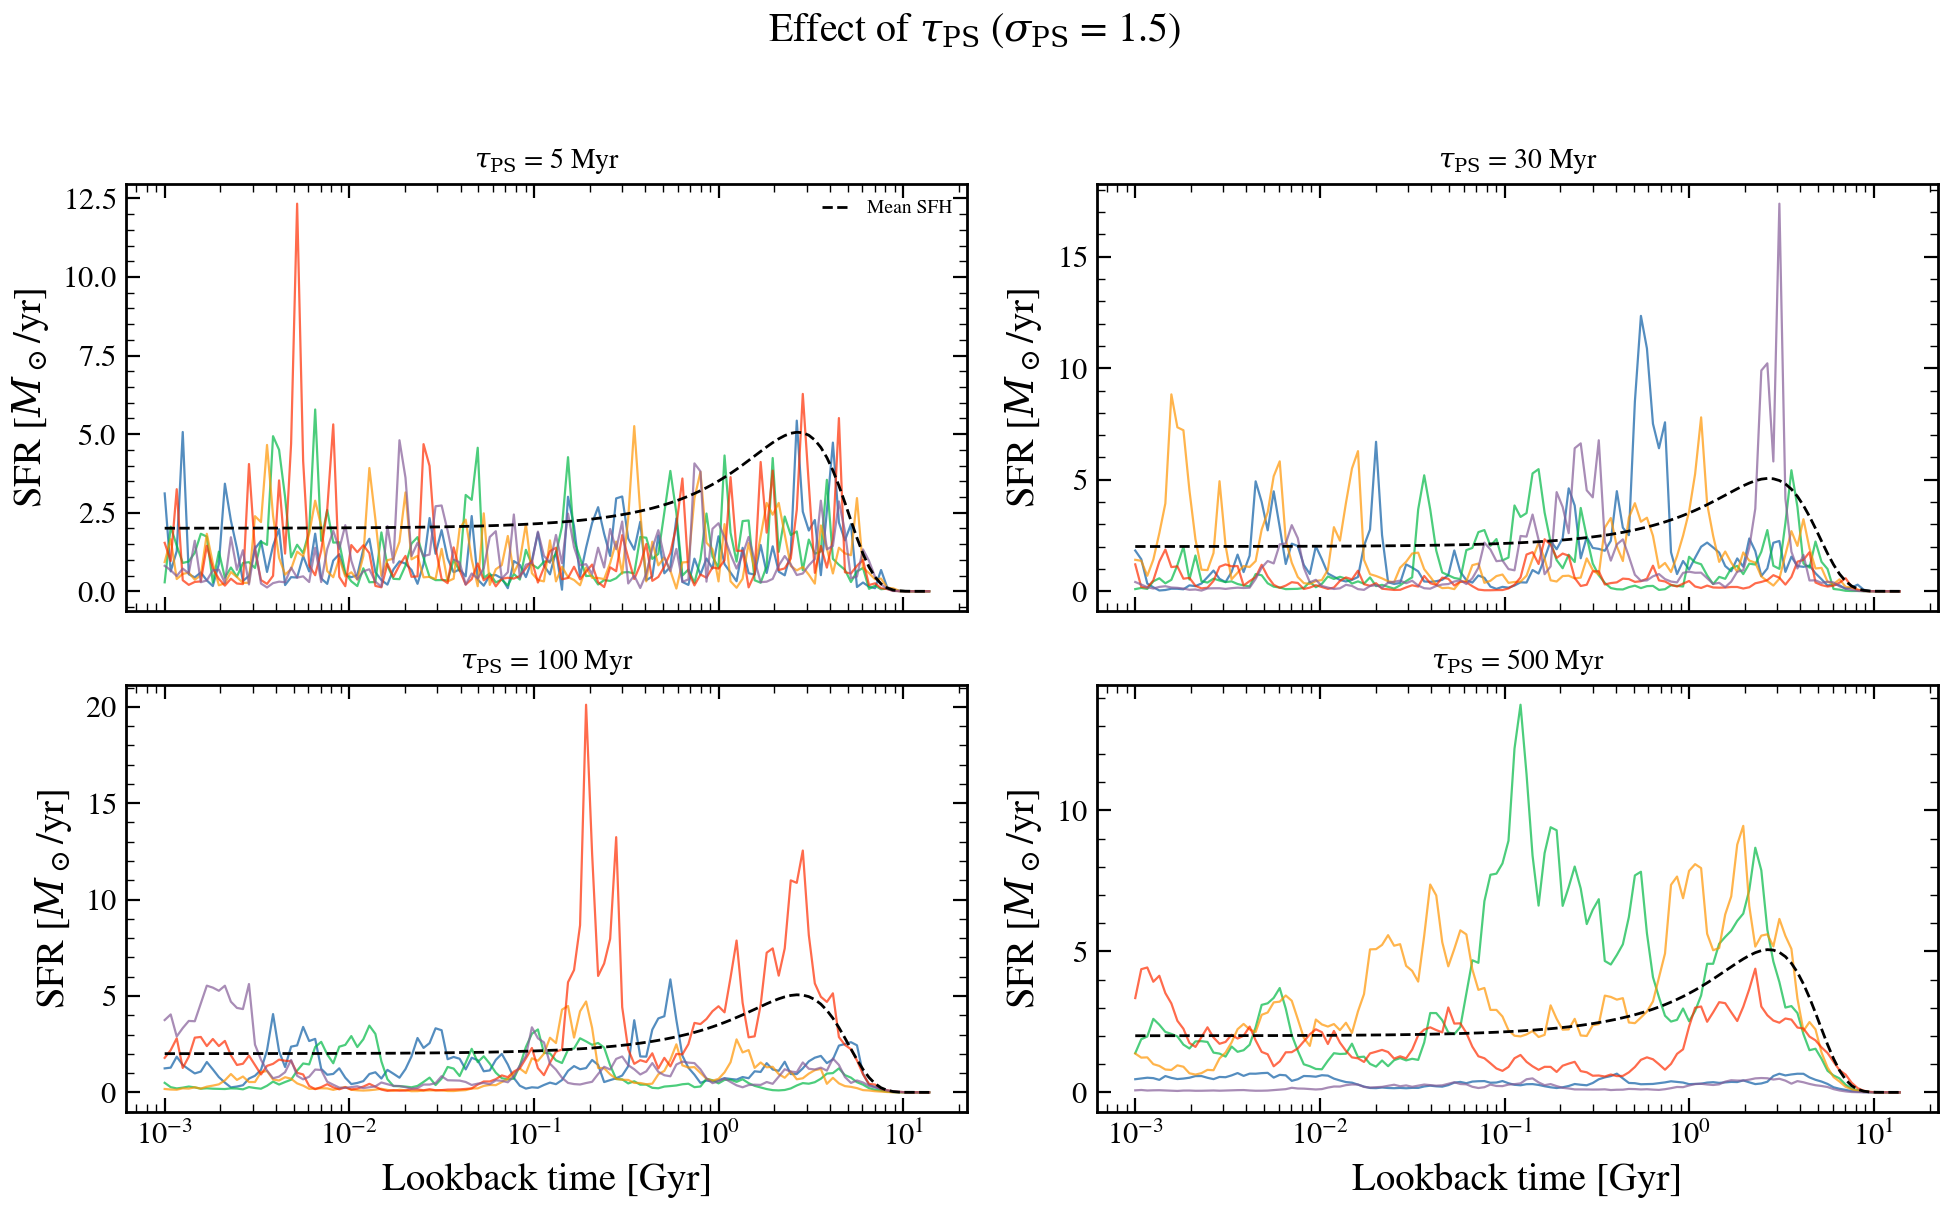

In [16]:
# --- FIGURE 7: SFH realizations at fixed sigma, varying tau ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
tau_values_myr = [5, 30, 100, 500]
sigma_fixed = 1.5

for idx, (ax, tau_myr) in enumerate(zip(axes.flat, tau_values_myr)):
    tau_yr = tau_myr * 1e6
    for i in range(5):
        subkey = jax.random.fold_in(key, i + idx * 100)
        sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_fixed, tau_yr)
        gp = generate_gp_fourier(subkey, sqrt_p, N_GRID)
        base_sfr = tsnorm(
            10**log_ages,
            log_peak_sfr=1.0,
            peak_lbt=3e9,
            width=2e9,
            skew=0.0,
            trunc=5.0,
        )
        var_x = drw_variance(sigma_fixed)
        full_sfr = base_sfr * jnp.exp(gp - var_x)
        ax.plot(ages_gyr, full_sfr, lw=0.8, alpha=0.7)
    ax.plot(ages_gyr, base_sfr, "k--", lw=1.0, label="Mean SFH")
    ax.set_title(f"$\\tau_{{\\rm PS}}$ = {tau_myr} Myr", fontsize=10)
    ax.set_xscale("log")
    ax.set_ylabel("SFR [$M_\\odot$/yr]")
axes[1, 0].set_xlabel("Lookback time [Gyr]")
axes[1, 1].set_xlabel("Lookback time [Gyr]")
axes[0, 0].legend(fontsize=7, frameon=False)
fig.suptitle(f"Effect of $\\tau_{{\\rm PS}}$ ($\\sigma_{{\\rm PS}}$ = {sigma_fixed})", y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_tau_effect.png"), bbox_inches="tight")
plt.show()

## 9. Literature Mapping Table

Connecting tengri PSD parameters to published SFH variability studies.

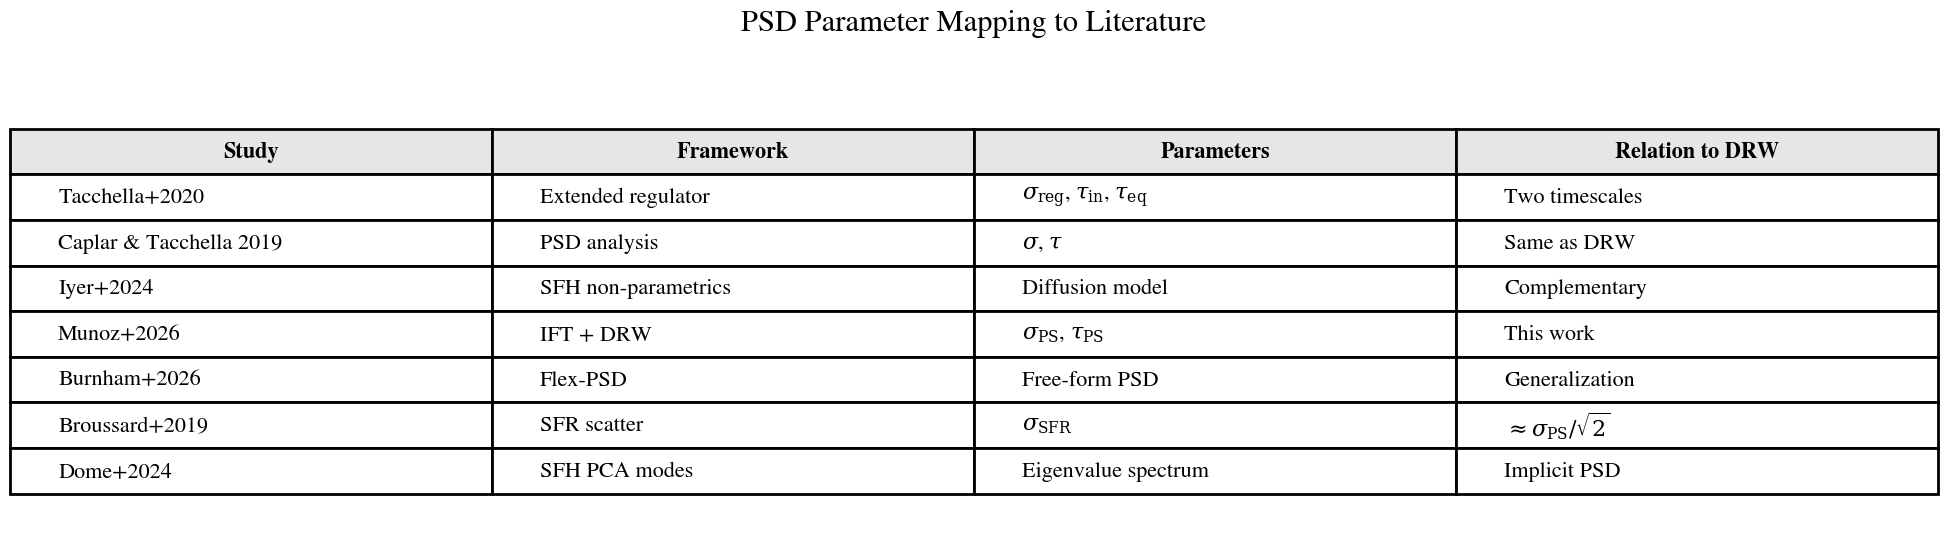

In [17]:
# --- FIGURE 8: Literature mapping table ---
table_data = [
    [
        "Tacchella+2020",
        "Extended regulator",
        r"$\sigma_{\rm reg}$, $\tau_{\rm in}$, $\tau_{\rm eq}$",
        "Two timescales",
    ],
    ["Caplar & Tacchella 2019", "PSD analysis", r"$\sigma$, $\tau$", "Same as DRW"],
    ["Iyer+2024", "SFH non-parametrics", "Diffusion model", "Complementary"],
    ["Munoz+2026", "IFT + DRW", r"$\sigma_{\rm PS}$, $\tau_{\rm PS}$", "This work"],
    ["Burnham+2026", "Flex-PSD", "Free-form PSD", "Generalization"],
    [
        "Broussard+2019",
        "SFR scatter",
        r"$\sigma_{\rm SFR}$",
        r"$\approx \sigma_{\rm PS}/\sqrt{2}$",
    ],
    ["Dome+2024", "SFH PCA modes", "Eigenvalue spectrum", "Implicit PSD"],
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
col_labels = ["Study", "Framework", "Parameters", "Relation to DRW"]
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.4)
for key_cell, cell in table.get_celld().items():
    if key_cell[0] == 0:
        cell.set_facecolor("#e6e6e6")
        cell.set_text_props(weight="bold")
ax.set_title("PSD Parameter Mapping to Literature", fontsize=11, pad=20)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_literature_table.png"), bbox_inches="tight")
plt.show()

## 10. Alternative PSD Models

The DRW is the default PSD in tengri, but the package also provides two
alternative models for situations where different spectral behaviour is
needed.

### 8a. Matern PSD

The Matern covariance family is parameterised by a smoothness parameter
$\nu$. Its 1-D spectral density is

$$P_{\rm Matern}(\omega) \propto \frac{\sigma^2}
  {\bigl(\lambda + \omega^2\bigr)^{\nu + 1/2}}, \qquad
  \lambda = \frac{2\nu}{\ell^2}$$

where $\ell$ is the length scale and $\sigma^2$ the marginal variance.
Key properties:

- **$\nu = 0.5$** recovers the DRW (Lorentzian) exactly.
- **Higher $\nu$** suppresses high-frequency power more steeply
  ($\propto \omega^{-(2\nu+1)}$ vs $\omega^{-2}$ for DRW), producing
  smoother GP realizations with fewer rapid oscillations.
- **$\nu \to \infty$** yields the squared-exponential (infinitely smooth)
  kernel.

Use Matern when the data favour smoother SFHs than the DRW allows, for
example in massive quiescent galaxies where star formation varies slowly.

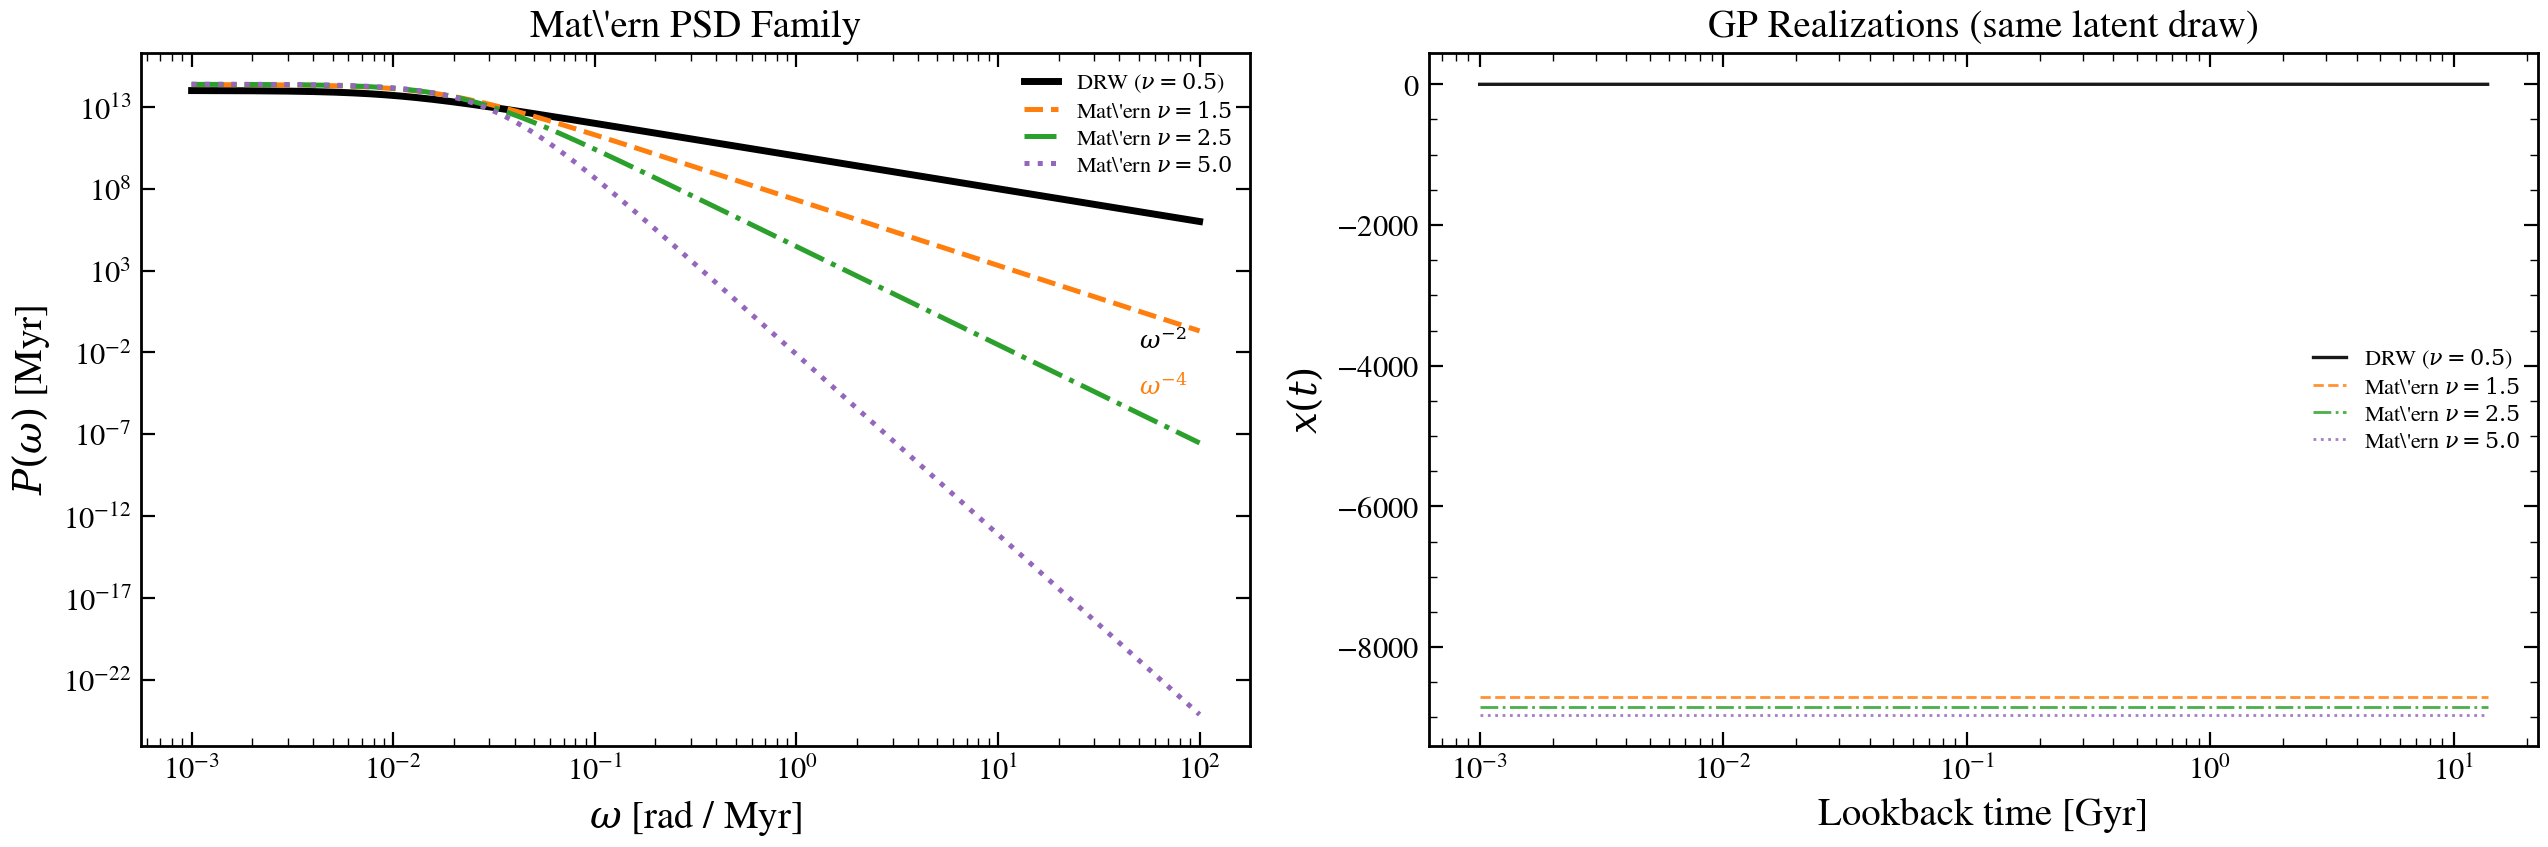

In [18]:
# --- FIGURE 9: Matern PSD family comparison (detailed) ---
from tengri.models.sfh.psd_models import psd_matern, psd_extended_regulator

omega_alt = np.logspace(-3, 2, 600)  # rad / Myr
sigma_alt, tau_myr_alt = 1.0, 100.0
tau_yr_alt = tau_myr_alt * 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: PSD comparison
ax = axes[0]
psd_ref = psd_drw(omega_alt / 1e6, sigma_alt, tau_yr_alt) * 1e6
ax.loglog(omega_alt, psd_ref, "k-", lw=2.5, label=r"DRW ($\nu = 0.5$)")

nu_values = [1.5, 2.5, 5.0]
nu_colors = [COLORS["geovi"], COLORS["nuts"], COLORS["mgvi"]]
nu_styles = ["--", "-.", ":"]
for nu, c, ls in zip(nu_values, nu_colors, nu_styles):
    psd_m = psd_matern(omega_alt / 1e6, sigma_alt**2, tau_yr_alt, nu) * 1e6
    ax.loglog(omega_alt, psd_m, ls=ls, color=c, lw=1.8, label=rf"Mat\'ern $\nu = {nu}$")

ax.set_xlabel(r"$\omega$ [rad / Myr]")
ax.set_ylabel(r"$P(\omega)$ [Myr]")
ax.set_title(r"Mat\'ern PSD Family")
ax.legend(fontsize=8, frameon=False)

# Annotate high-frequency slopes
ax.annotate(r"$\omega^{-2}$", xy=(50, 2e-2), fontsize=9, color="k")
ax.annotate(r"$\omega^{-4}$", xy=(50, 3e-5), fontsize=9, color=COLORS["geovi"])

# Right panel: GP realizations from each PSD
ax = axes[1]
key_alt = jax.random.PRNGKey(17)
xi = jax.random.normal(key_alt, shape=(N_GRID,))

# DRW realization
sqrt_p_drw = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_alt, tau_yr_alt)
gp_drw = gp_from_xi(xi, sqrt_p_drw, N_GRID)
ax.plot(ages_gyr, gp_drw, "k-", lw=1.2, alpha=0.9, label=r"DRW ($\nu = 0.5$)")

# Matern realizations (same xi for fair comparison)
from tengri.models.sfh.psd_models import psd_to_sqrt_power

omega_grid = 2.0 * jnp.pi * jnp.fft.rfftfreq(N_GRID, d=d_log_age)

for nu, c, ls in zip(nu_values, nu_colors, nu_styles):
    psd_vals = psd_matern(omega_grid, sigma_alt**2, tau_yr_alt, nu)
    sqrt_p_mat = psd_to_sqrt_power(psd_vals, d_log_age)
    gp_mat = gp_from_xi(xi, sqrt_p_mat, N_GRID)
    ax.plot(ages_gyr, gp_mat, ls=ls, color=c, lw=1.0, alpha=0.85, label=rf"Mat\'ern $\nu = {nu}$")

ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"$x(t)$")
ax.set_title("GP Realizations (same latent draw)")
ax.set_xscale("log")
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_matern_family.png"), bbox_inches="tight")
plt.show()

**Interpretation.** All four curves above use the *same* latent vector
$\xi$, so differences are entirely due to the PSD shape. Higher $\nu$
progressively filters out rapid fluctuations while preserving the
long-timescale structure. The DRW ($\nu = 0.5$) shows the most jagged
behaviour; $\nu = 5$ is almost sinusoidal.

### 8b. Extended Regulator PSD

The **extended regulator model** (Tacchella+2020; Caplar & Tacchella 2019)
decomposes SFH variability into two physical components:

$$P_{\rm ext}(f) = \frac{\sigma_{\rm reg}^2}
  {\bigl(1 + (2\pi f\,\tau_{\rm in})^2\bigr)
   \bigl(1 + (2\pi f\,\tau_{\rm eq})^2\bigr)}
  + \frac{\sigma_{\rm dyn}^2}
    {1 + (2\pi f\,\tau_{\rm dyn})^2}$$

where $f$ is the cyclic frequency (Hz, not angular).

- **Regulator term** (first): gas inflow on timescale $\tau_{\rm in}$
  equilibrated on $\tau_{\rm eq}$. This is a *double* Lorentzian with
  steeper high-frequency rolloff ($\propto f^{-4}$) than the DRW.
- **Dynamical term** (second): short-timescale stochastic variability
  from dynamical processes (e.g., spiral arms, GMC formation) on
  $\tau_{\rm dyn}$.

The sum of these two components produces a PSD with a **shoulder** at
intermediate frequencies, unlike the single-break DRW. This physically
encodes the idea that SFH variability has contributions from two
distinct mechanisms operating at different timescales.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89117/2567873279.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  er_var = float(np.trapz(psd_er, freq_hz))


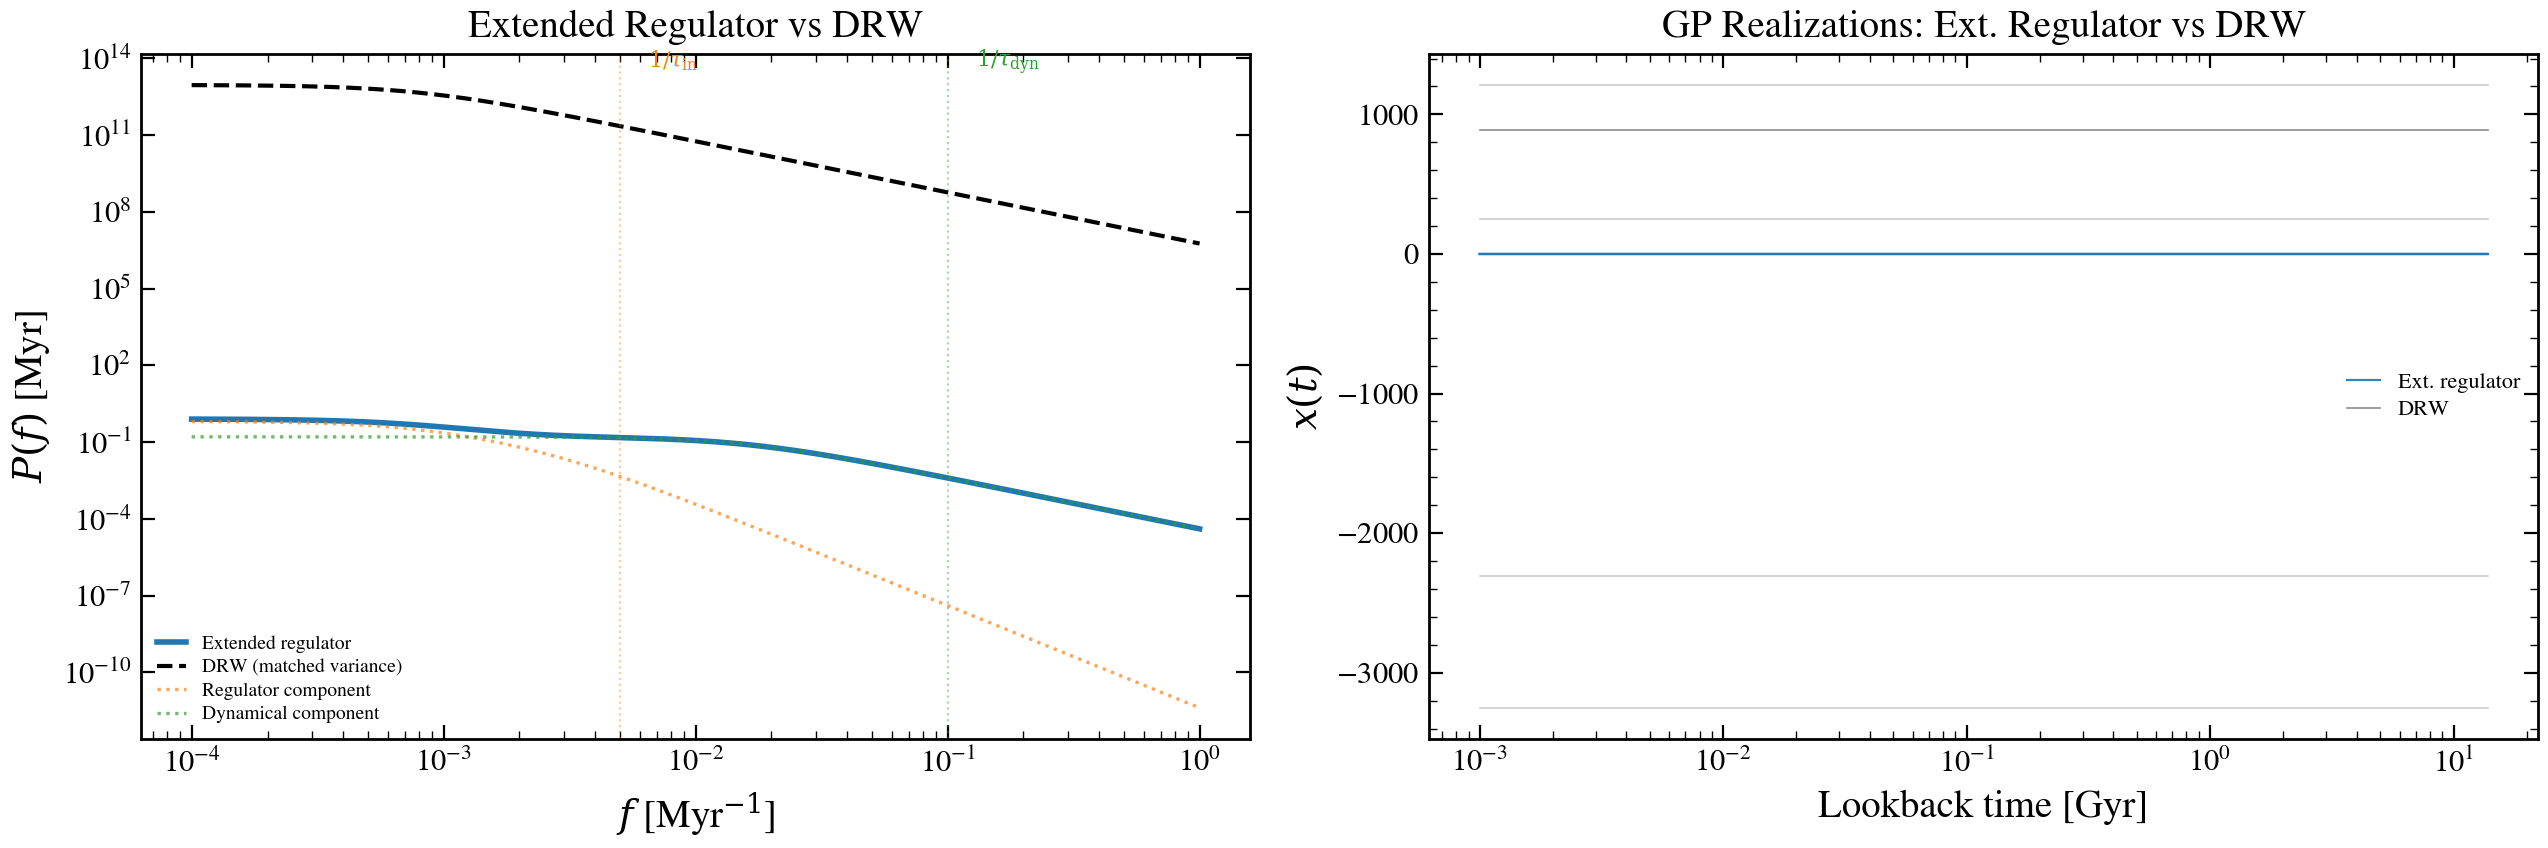

In [19]:
# --- FIGURE 10: Extended Regulator vs DRW ---
freq_hz = np.logspace(-4, 0, 600)  # cyclic frequency in Myr^-1
omega_er = 2.0 * np.pi * freq_hz  # angular frequency for DRW comparison

# Extended regulator fiducial parameters (Tacchella+2020 inspired)
s_reg = 0.8  # regulator amplitude
tau_in = 200.0  # inflow timescale [Myr]
tau_eq = 50.0  # equilibrium timescale [Myr]
s_dyn = 0.4  # dynamical amplitude
tau_dyn_myr = 10.0  # dynamical timescale [Myr]

psd_er = psd_extended_regulator(freq_hz, s_reg, tau_in, tau_eq, s_dyn, tau_dyn_myr)

# DRW matched to same total variance (for fair visual comparison)
# Total variance of ext. regulator = integral P(f) df ≈ numerical
er_var = float(np.trapz(psd_er, freq_hz))
# DRW variance = sigma^2 / (4 pi tau) in cyclic frequency
# Match by setting sigma^2 * tau = 2 * er_var
sigma_match = np.sqrt(2.0 * er_var / (tau_in * 1e-3))
tau_match_yr = tau_in * 1e6
psd_drw_match = psd_drw(omega_er / 1e6, sigma_match, tau_match_yr) * 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: PSD comparison
ax = axes[0]
ax.loglog(freq_hz, psd_er, color=COLORS["rt"], lw=2.0, label="Extended regulator")
ax.loglog(freq_hz, psd_drw_match, "k--", lw=1.5, label="DRW (matched variance)")

# Show individual components
psd_reg_only = psd_extended_regulator(freq_hz, s_reg, tau_in, tau_eq, 0.0, tau_dyn_myr)
psd_dyn_only = psd_extended_regulator(freq_hz, 0.0, tau_in, tau_eq, s_dyn, tau_dyn_myr)
ax.loglog(
    freq_hz,
    psd_reg_only,
    ":",
    color=COLORS["geovi"],
    lw=1.2,
    alpha=0.7,
    label="Regulator component",
)
ax.loglog(
    freq_hz,
    psd_dyn_only,
    ":",
    color=COLORS["nuts"],
    lw=1.2,
    alpha=0.7,
    label="Dynamical component",
)

ax.set_xlabel(r"$f$ [Myr$^{-1}$]")
ax.set_ylabel(r"$P(f)$ [Myr]")
ax.set_title("Extended Regulator vs DRW")
ax.legend(fontsize=7, frameon=False)

# Annotate the two breaks
ax.axvline(1.0 / tau_in, color=COLORS["geovi"], ls=":", alpha=0.4, lw=0.8)
ax.axvline(1.0 / tau_dyn_myr, color=COLORS["nuts"], ls=":", alpha=0.4, lw=0.8)
ax.text(
    1.0 / tau_in * 1.3,
    ax.get_ylim()[1] * 0.3,
    r"$1/\tau_{\rm in}$",
    fontsize=8,
    color=COLORS["geovi"],
)
ax.text(
    1.0 / tau_dyn_myr * 1.3,
    ax.get_ylim()[1] * 0.3,
    r"$1/\tau_{\rm dyn}$",
    fontsize=8,
    color=COLORS["nuts"],
)

# Right: GP realizations
ax = axes[1]
key_er = jax.random.PRNGKey(99)
n_real = 5

# Extended regulator realizations via Fourier synthesis
omega_grid_er = 2.0 * jnp.pi * jnp.fft.rfftfreq(N_GRID, d=d_log_age)
freq_grid_er = omega_grid_er / (2.0 * jnp.pi)

psd_er_grid = psd_extended_regulator(
    jnp.abs(freq_grid_er), s_reg, tau_in, tau_eq, s_dyn, tau_dyn_myr
)
sqrt_p_er = psd_to_sqrt_power(psd_er_grid, d_log_age)

psd_drw_grid = psd_drw(omega_grid_er, sigma_match, tau_match_yr)
sqrt_p_drw_match = psd_to_sqrt_power(psd_drw_grid, d_log_age)

for i in range(n_real):
    subkey = jax.random.fold_in(key_er, i)
    xi_er = jax.random.normal(subkey, shape=(N_GRID,))
    gp_er = gp_from_xi(xi_er, sqrt_p_er, N_GRID)
    gp_drw_r = gp_from_xi(xi_er, sqrt_p_drw_match, N_GRID)
    alpha = 0.9 if i == 0 else 0.4
    lbl_er = "Ext. regulator" if i == 0 else None
    lbl_drw = "DRW" if i == 0 else None
    ax.plot(ages_gyr, gp_er, color=COLORS["rt"], lw=0.8, alpha=alpha, label=lbl_er)
    ax.plot(ages_gyr, gp_drw_r, "k-", lw=0.6, alpha=alpha * 0.5, label=lbl_drw)

ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"$x(t)$")
ax.set_title("GP Realizations: Ext. Regulator vs DRW")
ax.set_xscale("log")
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_extended_regulator.png"), bbox_inches="tight")
plt.show()

**Interpretation.** The extended regulator PSD has a characteristic
shoulder between the two break frequencies. In the GP realizations, this
manifests as smoother long-timescale trends (from the regulator
component) punctuated by sharper short-timescale flickers (from the
dynamical component). The DRW, by contrast, has a single characteristic
timescale and cannot separate these two modes of variability.

### 8c. When to Use Which PSD

| PSD model | Parameters | Best for | Limitations |
|-----------|-----------|----------|-------------|
| **DRW** | $\sigma_{\rm PS}$, $\tau_{\rm PS}$ (2 free) | Default choice; simplest model; sufficient for most photometric SED fits | Single break frequency; cannot separate physical mechanisms |
| **Matern** | $\sigma^2$, $\ell$, $\nu$ (3 free) | Smoother SFHs (massive/quiescent galaxies); tunable high-frequency rolloff | Extra parameter; $\nu$ poorly constrained by broadband photometry alone |
| **Extended regulator** | $\sigma_{\rm reg}$, $\tau_{\rm in}$, $\tau_{\rm eq}$, $\sigma_{\rm dyn}$, $\tau_{\rm dyn}$ (5 free) | Physically motivated dual-timescale models; connecting to gas regulation theory | Many parameters; requires spectroscopy or H-alpha to constrain both timescales |

**Practical guidance:**

- Start with the **DRW** (2 parameters). It is the default in tengri and
  sufficient for most applications.
- Switch to **Matern** if residuals show the DRW is too jagged (too much
  high-frequency power) for the galaxy population being studied.
- Use the **extended regulator** when you want to connect SFH inference
  to gas regulation physics, or when multi-wavelength data (especially
  H-alpha + UV) can constrain multiple timescales simultaneously.

## Physical Interpretation

| σ_PS | τ_PS | Physical regime |
|------|------|----------------|
| 0.3–0.5 | 100–300 Myr | Secular evolution (disk galaxies) |
| 0.5–1.5 | 20–100 Myr | Gas cycling, minor mergers |
| 1.5–2.5 | 5–50 Myr | SN feedback, dwarf starbursts |
| > 2.5 | < 10 Myr | Extreme dwarf, first galaxies |

These connect to simulations (Tacchella+2020, FIRE) and observed main-sequence
scatter (Caplar & Tacchella 2019, Iyer+2024).

## Summary

The PSD is a two-parameter prior that encodes physically motivated burstiness.
The framework accepts any PSD — DRW is just the default. The standardization
trick (ξ ~ N(0,I)) makes all inference methods work identically.

Next: **tutorials/04** shows how an SFH becomes an observable spectrum
through the differentiable forward model.